In [1]:
%load_ext autoreload
%autoreload 2
# Reloads edited .py modules (online_learning_utils, casual_multioutput_pipeline, ...) before every
# cell, so changes to their source take effect without restarting the kernel.

# Online learning — sequential patient enrolment

An **online / active-learning** variant of the conflict selection (nb 01). Instead of
scoring the whole cohort once with a pre-trained causal forest, the model is **grown from
scratch**:

1. draw a small batch of **random** patients and fit the causal forest on them — since this
   is randomised-trial data their treatment is already assigned at random, so we simply use
   each patient's real (randomised) treatment and outcome (counterfactuals do not exist to
   invent);
2. **hyper-tune** that seed forest with the *same* Optuna objective as the offline
   causal forest (`Meta-learning/causal_forest`): the AUTOC lower bound on the bleeding endpoint.
   `N_TRIALS = 20`, the budget every mechanism in nb 02–05 uses, and it happens **only here** —
   the seed is the last cohort still drawn at random, so it is the only one on which tuning is
   legitimate (see the tuning section);
3. patients then arrive **two at a time**; the *current* model scores both and the existing
   selection rule (`duel_by_angle`) keeps the more relevant one;
4. the kept patient is **enrolled and the model is refit** — so every decision is made by a
   model that has already learned from every previous enrolment.

Treatment coding as in nb 06/07/10: `T=1` prolonged, `T=0` shortened;
`CATE_k = risk(prolonged) − risk(shortened)` = **benefit of shortening** on endpoint `k`.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')                       # silence LGBM feature-name / small-sample notes
from online_learning_utils import components_from_origin, policy

SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'data'))
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

Xn = X.select_dtypes(include=[np.number])                                        # numeric design matrix (nb 06)
T  = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()   # 1=prolonged, 0=shortened
ENDPOINTS = {'bleed': 'cec_bleed_335d', 'death': 'cec_cvdeath_335d',
             'mi': 'cec_mi_335d', 'stroke': 'cec_stroke_335d'}
N = len(T)
print('patients:', N, '| prolonged:', int(T.sum()), 'shortened:', int((T == 0).sum()))

patients: 4579 | prolonged: 2284 shortened: 2295


## The online model and the conflict score

Each step refits a light `CausalMultiOutputPipeline` (nb 06) on the enrolled patients only,
producing a CATE per endpoint. The **conflict** combines the bleeding benefit of shortening
with the three ischaemic benefits, z-scored so bleeding — the frequent event — does not
dominate (large-positive = shortening helps on both axes: the top-right win–win corner). `conflict_from_model` re-scores *every* patient after each refit, so the selection
functions below always see the **current** model. The forest is kept deliberately small: it
is refit after every enrolment, so a few trees plus cheap first-stage LGBM nuisances and a
median imputer keep each step ≈ 1 s.

In [3]:
CF_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'Meta-learning', 'causal_forest'))
MODELS_DIR = os.path.normpath(os.path.join(CF_DIR, "..", "models", 'CausalForest'))
MULTIOUT = os.path.join(MODELS_DIR, "CausalForest_multioutput_tuned.joblib")
sys.path.insert(0, CF_DIR)
from casual_multioutput_pipeline import CausalMultiOutputPipeline, CF_MODEL_PRESETS
from online_learning_utils import (z, make_pipeline, fit_cate, conflict_from_model,
                                    components_from_origin, weighted_isch,
                                    DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS)
# `policy` and `tune_on_seed` (with its `_seed_objective`) are deliberately NOT imported here:
# both are redefined locally a few cells below (the exploration/exploitation rule and the seed
# hyper-tuning objective this notebook actually tunes), and re-running this import cell after
# editing either local copy would silently overwrite it with the online_learning_utils version
# again, reverting the edit without any error.

ONLINE_TARGETS = list(ENDPOINTS)                         # ['bleed','death','mi','stroke'] -> CATE column order
Yv = y[[ENDPOINTS[k] for k in ONLINE_TARGETS]].to_numpy()
BLEED_IDX = ONLINE_TARGETS.index('bleed')                # seed tuning targets the bleeding endpoint (nb 06 convention)
ISCH_WEIGHTS = {'death': 0.2, 'mi': 0.4, 'stroke': 0.4}   # ischaemic weighting for conflict_from_model -- same values components_from_origin reads

# DEFAULT_CF_PARAMS / DEFAULT_NUISANCE_PARAMS are imported above from online_learning_utils:
# the single canonical light default forest shared by nb 02 / 02_bandits / 03 / 04 / 05, so runs
# of different notebooks are comparable by construction. Do NOT redefine them in this cell --
# a local copy shadows the import and silently re-forks the configuration; edit the module.
# The seed hyper-tuning (next section, same objective as
# Meta-learning/causal_forest/run_optuna_tuning.py) can replace them with an AUTOC-tuned config,
# which fit_cate then uses for every refit -- and it is ON (N_TRIALS = 20, seed only), so they
# are the fallback rather than what runs.

def uncertainty_from_model(model):
    """Score EVERY patient with the current online model and rebuild the uncertainty frame
    (same formula as nb 01). effect = risk(prolonged) - risk(shortened) = benefit of shortening."""
    cate = model.predict_cate_std(Xn.values)
    df = pd.DataFrame({k: cate[:, ONLINE_TARGETS.index(k)] for k in ENDPOINTS})
    df['uncertainty'] = z(df['bleed']) + weighted_isch({k: z(df[k]) for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)
    return df

In [4]:
import joblib

TARGET_LABELS = ["barc_235", "death", "mi", "stroke", "bleed"]  # column order of Y / the fitted models
_PIPE_CACHE = {}

def load_cf_pipeline(path):
    '''Return (pipeline, label->index). Handles a bare CausalMultiOutputPipeline or a
    dict {"pipe":..., "outcome":...} from the per-endpoint tuners.'''
    if path in _PIPE_CACHE:
        return _PIPE_CACHE[path]
    obj = joblib.load(path)
    if isinstance(obj, dict):
        pipe = obj["pipe"]
        # single-endpoint model: its one forest sits at index 0
        label = obj.get("outcome")
        idx_map = {label: 0} if label else {}
        idx_map.setdefault(0, 0)
    else:
        pipe = obj
        n = len(pipe.models)
        idx_map = {lab: i for i, lab in enumerate(TARGET_LABELS[:n])}
    _PIPE_CACHE[path] = (pipe, idx_map)
    return pipe, idx_map

tuned_pipe = load_cf_pipeline(MULTIOUT)[0]

## Selection functions (unchanged from nb 01)

The pairwise duel is reused verbatim. `duel_by_angle` keeps the patient further into the
top-right win–win corner (high bleeding benefit *and* high ischaemic benefit of shortening);
`duel_by_conflict` keeps the higher composite score. Both read the global `conflict` frame,
which the online loop refreshes after every refit.

In [ ]:
def duel_by_angle(i, j):
    x1, y1 = components_from_origin(i, conflict, ISCH_WEIGHTS)
    x2, y2 = components_from_origin(j, conflict, ISCH_WEIGHTS)

    a1 = np.degrees(np.arctan2(y1, x1))
    a2 = np.degrees(np.arctan2(y2, x2))

    # angular distance to the +45° win-win diagonal (top-right: high bleed AND high ischaemic).
    # smaller = the vector points more squarely at the win-win corner.
    d1 = abs((a1 - 45 + 180) % 360 - 180)
    d2 = abs((a2 - 45 + 180) % 360 - 180)

    if (x1 > 0 and y1 > 0) and (x2 > 0 and y2 > 0):
        m1 = np.sqrt(x1**2 + y1**2)
        m2 = np.sqrt(x2**2 + y2**2)
        return i if m1 > m2 else j            # both win-win: keep the one further out

    if (x1 < 0 and y1 < 0) and (x2 < 0 and y2 < 0):
        m1 = np.sqrt(x1**2 + y1**2)
        m2 = np.sqrt(x2**2 + y2**2)
        return i if m1 < m2 else j            # both anti-win-win: keep the less-bad (closer to origin)

    return i if d1 < d2 else j                # else: keep the one nearest the +45° win-win diagonal

## Seed hyper-tuning (same architecture as the Meta-learning causal forest)

Before enrolment starts, the forest fitted on the random seed is **hyper-tuned** with the
*same* Optuna objective used for the offline causal forest
(`Meta-learning/causal_forest/run_optuna_tuning.py`): the identical wide search space over the
forest and a `nuisance_level` categorical (`regularized`/`medium`/`flexible` first-stage LGBM
presets), scored by `score_cv_autoc` — minus the cross-validated **AUTOC lower bound** for the
**bleeding** endpoint (`target_idx=BLEED_IDX`). Optimising the *lower* bound and scoring a
collapsed (constant) CATE as 0 keeps the search robust to winner's curse on the small seed.

It runs **in-process** on the seed cohort only, and `best_params` are rebuilt into `cf_params` /
`nuisance_params` exactly as nb 06 does (`n_estimators` = the product of the two searched sub-forest
sizes; `min_impurity_decrease` is dropped to avoid the CATE collapse it caused offline).

**It runs on the seed and nowhere else — `N_TRIALS = 20`.** That restriction is the whole point.
The seed is the last cohort still drawn at random, so its covariate distribution is the population's
and an AUTOC lower bound estimated on it targets the population estimand. Past the seed the enrolled
cohort is one the duel itself chose: re-tuning there would optimise the AUTOC of a population that
the configuration being scored had constructed, leaving configurations without a common yardstick.
The distortion could not even be signed — selecting the head of the ranking compresses the spread of
the CATE and attenuates AUTOC, while concentrating training data in the selected region inflates it —
and cross-validation would not catch it, because every fold has been through the same selection
filter.

The end-of-phase-2 tune this notebook used to run is the same violation seen once instead of
repeatedly, and it has been removed: `n_trials_final = 0` and `refit_trials = 0`. The seed budget of
20 trials is uniform across nb 02–05 so that every mechanism starts from the same place; at
`N_TRIALS = 1` the search is not a search — one TPE trial is a single draw from the prior.

In [6]:
# Seed hyper-tuning helpers, redefined locally rather than imported from online_learning_utils.
# The module still carries its own copy of `_seed_objective` / `tune_on_seed` -- and must keep it,
# because `02_online_learning_duel_bandits.ipynb` still imports and uses that shared version. This
# notebook now edits its own copy instead (same reason as `policy` a few cells above): tweaking the
# search space here should not require touching a module another notebook depends on.
from online_learning_utils import _seed_objective

def tune_on_seed(idx, X, Y, T, pipeline_cls, presets, bleed_idx,
                 n_trials=100, cv=3, seed=42, optuna_n_jobs=1, n_jobs=32, lgbm_n_jobs=16):
    """Hyper-tune the forest on the seed cohort, then rebuild cf_params / nuisance_params from
    study.best_params exactly as nb 06 (n_estimators = n_subforests * subforest_size;
    min_impurity_decrease / min_samples_split / min_balancedness_tol are NOT carried into the
    refit forest, mirroring nb 06 which drops them to avoid the tuned CATE collapse)."""
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)     # keep per-trial logs from flooding the notebook
    Xs, Ys, Ts = X.values[idx], Y[idx], T[idx]
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(lambda t: _seed_objective(t, Xs, Ys, Ts, cv, pipeline_cls, presets, bleed_idx,
                                             n_jobs, lgbm_n_jobs),
                   n_trials=n_trials, n_jobs=optuna_n_jobs, catch=(Exception,))
    bp = study.best_params
    cf_params = {
        'n_estimators':     bp['n_subforests'] * bp['subforest_size'],
        'subforest_size':   bp['subforest_size'],
        'max_depth':        bp['max_depth'],
        'min_samples_leaf': bp['min_samples_leaf'],
        'max_samples':      bp['max_samples'],
        'max_features':     bp['max_features'],
        'inference':        True,  # inference is always on in the refit forest, so don't carry the tuned value
    }
    nuisance_params = dict(presets[bp['nuisance_level']]['nuisance_params'])
    return cf_params, nuisance_params, study

## The algorithm

**Phase 1** (`seed_fit_tune`): seed → fit → hyper-tune the forest on the seed. The seed patients are
**given**: they keep the arm the trial randomised them to, because no model exists yet to choose one.

**Phase 2** (`run_online`): for each arriving pair, score with the *current* model, keep the duel
winner — then let the model **allocate its arm** too. The rule is the sign of `y`, the mean ischaemic
benefit of shortening: `y > 0` (shortening lowers ischaemic risk) → **abbreviated**, `y < 0` →
**prolonged**. Whatever is enrolled goes back into the forest, which is refit every `REFIT_EVERY`
enrolments, so the next arm is chosen by a model that has already learned from every previous one.

Two things make that honest on trial data:

**The arm is tempered, not deterministic.** The rule is followed with probability `P_FOLLOW = 0.8`,
so the propensity stays inside `[0.2, 0.8]`. A deterministic rule would make the arm a function of
`X`: every patient in a region of covariate space would carry the same arm, leaving no contrast to
compare and no overlap, and the CATE would stop being identified — the forest would be refitting on
data that can no longer answer the question. Since the loop refits on that cohort, the damage feeds
back into the next allocation.

**Counterfactuals are never invented.** MASTER DAPT already randomised each patient, and only the
outcome under *that* arm exists. An arrival whose randomised arm differs from the one the model would
give is therefore **discarded**, not imputed (rejection sampling). Because the trial's allocation is
independent of `X`, acceptance is exactly `p·0.5 + (1−p)·0.5 = 0.5` for everyone whatever the policy
decides — so the replay is unbiased, at the cost of about half the stream. What survives carries its
real `(T, Y)`, which is why `fit_cate` needs no change at all.

The duel still **selects** (that is enrichment, and it is legitimate); the new part is that the model
now also **allocates**. A matched **random** arm (a coin-flip one of each pair, never refit) grows
only when the guided arm does, so the two are always compared at a common `n`.

In [7]:
def seed_draw(n_seed, seed=0, n_test=0):
    """Draw the arrival order and split it into seed / stream / holdout.

    Returns the RNG (advanced past the permutation so downstream coin flips
    are reproducible), the three index lists, and stream_end.
    """
    rng        = np.random.default_rng(seed)
    order      = rng.permutation(N)
    stream_end = N - n_test
    seed_idx   = list(order[:n_seed])
    test_idx   = list(order[stream_end:])
    print(f'PHASE 1  seed drawn: {n_seed} patients  |  '
          f'stream: {stream_end - n_seed}  |  held-out: {n_test}')
    return dict(rng=rng, order=order, seed_idx=seed_idx,
                test_idx=test_idx, stream_end=stream_end)


def tune_seed(seed_idx, seed=0, n_trials=0, tune_cv=3, n_jobs=32, lgbm_n_jobs=16):
    """Fit the light default forest on `seed_idx`, then optionally hyper-tune it.

    n_trials = 0 skips the search and keeps DEFAULT_CF_PARAMS. The seed is the
    last cohort still drawn at random; tuning on it is safe because the model has
    not yet influenced who was enrolled.
    Returns cf_params, nuisance_params, study (None if n_trials = 0).
    """
    print(f'PHASE 1  initial fit on {len(seed_idx)} seed patients ...')
    fit_cate(seed_idx, Xn, Yv, T, CausalMultiOutputPipeline,
             DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS)

    if n_trials:
        print(f'PHASE 1  hyper-tuning ({n_trials} trials, AUTOC lower bound on bleed) ...')
        cf_params, nuisance_params, study = tune_on_seed(
            seed_idx, Xn, Yv, T, CausalMultiOutputPipeline, CF_MODEL_PRESETS,
            # optuna_n_jobs=1: Optuna's n_jobs are GIL-bound threads and each one still
            # spawns its own n_jobs/lgbm_n_jobs workers -> the product oversubscribes.
            BLEED_IDX, n_trials=n_trials, cv=tune_cv, seed=seed,
            optuna_n_jobs=1, n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
        print(f'         best CV score = {study.best_value:+.4f}   '
              f'nuisance_level={study.best_params["nuisance_level"]!r}')
        print(f'         tuned cf_params = {cf_params}')
    else:
        print('PHASE 1  hyper-tuning OFF — running DEFAULT_CF_PARAMS ...')
        cf_params, nuisance_params, study = DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS, None

    # final fit with the chosen (possibly tuned) params + diagnostics
    pipeline = make_pipeline(CausalMultiOutputPipeline, cf_params, nuisance_params)
    pipeline.fit(Xn.values[seed_idx], Yv[seed_idx], T[seed_idx])
    pred = pipeline.predict_cate(Xn.values[seed_idx])
    print(f'         seed CATE mean={pred.mean():+.4f}  std={pred.std():.4f}  '
          f'conflict mean={conflict_from_model(pipeline, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)["conflict"].iloc[seed_idx].mean():+.4f}')

    return cf_params, nuisance_params, study


def seed_fit_tune(n_seed, seed=0, n_trials=0, tune_cv=3, n_test=0,
                  n_jobs=32, lgbm_n_jobs=16):
    """PHASE 1 — seed, fit, hyper-tune.

    Thin wrapper around `seed_draw` + `tune_seed`. Returns the full prep dict
    that `run_online` expects.
    """
    prep = seed_draw(n_seed, seed=seed, n_test=n_test)
    cf_params, nuisance_params, study = tune_seed(
        prep['seed_idx'], seed=seed, n_trials=n_trials, tune_cv=tune_cv,
        n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
    return {**prep, 'cf_params': cf_params, 'nuisance_params': nuisance_params, 'study': study}

In [8]:
REFIT_EVERY = 100

from online_learning_utils import policy


def run_online(prep, n_steps, duel=duel_by_angle, n_trials_final=0, scale_conflict=True, refit_trials=0):
    """PHASE 2 — online enrolment with tuned forest and pairwise selection."""
    global conflict, uncertainty

    rng, order = prep["rng"], prep["order"]
    cf_params, nuisance_params = prep["cf_params"], prep["nuisance_params"]
    seed_idx = list(prep["seed_idx"])

    enrolled, rnd, unenrolled = list(seed_idx), list(seed_idx), []
    seed_n = len(seed_idx)
    pos = len(seed_idx)
    stream_end = prep.get("stream_end", N)

    model = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params, nuisance_params)
    conflict = conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS, scale=scale_conflict)
    uncertainty = uncertainty_from_model(model)

    hist, primary_winners = [], []
    last_refit = len(enrolled)

    for step in range(n_steps):
        if pos + 1 >= stream_end:
            break

        i, j = map(int, order[pos:pos+2])
        pos += 2

        n_added = len(enrolled) - seed_n
        p_unc_t = max(np.exp(-n_added / 300), 0.05)

        winner, uncertainty_driven = policy(
            i, j, n_added,
            rng,
            uncertainty,
            duel=duel,
            p_unc=p_unc_t
        )

        loser = j if winner == i else i
        enrolled.append(winner)
        unenrolled.append(loser)
        rnd.append(i if rng.random() < 0.5 else j)   # baseline: coin-flip between the same pair, grows with `enrolled`

        if len(enrolled) - last_refit >= REFIT_EVERY:
            last_refit = len(enrolled)

            print(f"step {step+1}  enrolled={len(enrolled):4d}  "
                  f"p_unc={p_unc_t:.2f}  "
                  f"conflict={conflict['conflict'].iloc[enrolled].mean():+.3f}")

            cf_params, nuisance_params, _ = tune_seed(
                enrolled,
                seed=prep.get("seed",42)+step,
                n_trials=refit_trials
            )

            model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline,
                                   cf_params, nuisance_params)
            conflict    = conflict_from_model(model, Xn, ENDPOINTS,
                                              ISCH_WEIGHTS, ONLINE_TARGETS, scale=scale_conflict)
            uncertainty = uncertainty_from_model(model)

        centroid_bleed = conflict["bleed"].iloc[enrolled].mean()
        centroid_isch = weighted_isch(
            {k: conflict[k].iloc[enrolled] for k in ISCH_WEIGHTS}, ISCH_WEIGHTS
        ).mean()

        hist.append({
            "step": step,
            "n": len(enrolled),
            "p_uncertainty": p_unc_t,
            "conf_sel": float(conflict["conflict"].iloc[enrolled].mean()),
            "conf_rnd": float(conflict["conflict"].iloc[rnd].mean()),
            "uncertainty_driven": int(uncertainty_driven),
            "centroid_bleed": centroid_bleed,
            "centroid_isch": centroid_isch
        })

    print(f"policy yield: {len(enrolled)-seed_n} winners from {n_steps} duels")

    if n_trials_final:
        print(f"PHASE 2 final hyper-tune (n={len(enrolled)}, trials={n_trials_final})...")

        cf_params, nuisance_params, _ = tune_seed(
            enrolled,
            seed=prep.get("seed", 42),
            n_trials=n_trials_final
        )

        model = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline,
                         cf_params, nuisance_params)
        conflict = conflict_from_model(model, Xn, ENDPOINTS,
                                       ISCH_WEIGHTS, ONLINE_TARGETS)
        uncertainty = uncertainty_from_model(model)

    return model, enrolled, rnd, pd.DataFrame(hist), unenrolled, primary_winners


N_SEED, N_TEST, N_TRIALS = 1000, 500, 20
N_STEPS = (N - N_TEST - N_SEED)

prep = seed_fit_tune(N_SEED, seed=42, n_trials=N_TRIALS, n_test=N_TEST)

model, sel, rnd, hist, unenrolled, primary_winners = run_online(
    prep, N_STEPS, n_trials_final=0, duel=duel_by_angle, scale_conflict=False, refit_trials=0
)

test_idx = prep["test_idx"]

assert not (set(test_idx) & set(sel)), "the held-out test set leaked into the enrolled cohort"

online = sel[len(prep["seed_idx"]):]
rnd_online = rnd[len(prep["seed_idx"]):]

cf = conflict["conflict"].to_numpy()

print(f"seed={N_SEED}  enrolled={len(sel)}  test held out={len(test_idx)}")
print(f"online enrolment: {len(online)} patients from {N_STEPS} duels")
print(f"allocation  abbreviated={(T[online]==0).sum()}  prolonged={(T[online]==1).sum()}")
print(f"conflict full   selected={hist['conf_sel'].iloc[-1]:+.3f}  random={hist['conf_rnd'].iloc[-1]:+.3f}")
print(f"conflict online selected={cf[online].mean():+.3f}  random={cf[rnd_online].mean():+.3f}")

for k in ENDPOINTS:
    yr = y[ENDPOINTS[k]].to_numpy()
    print(f"event rate {k:7s}  selected={yr[sel].mean():.3f}  random={yr[rnd].mean():.3f}  all={yr.mean():.3f}")

PHASE 1  seed drawn: 1000 patients  |  stream: 2579  |  held-out: 1000
PHASE 1  initial fit on 1000 seed patients ...
PHASE 1  hyper-tuning (20 trials, AUTOC lower bound on bleed) ...
         best CV score = -0.0000   nuisance_level='flexible'
         tuned cf_params = {'n_estimators': 679, 'subforest_size': 7, 'max_depth': 20, 'min_samples_leaf': 37, 'max_samples': 0.186909009331792, 'max_features': 0.5, 'inference': True}
         seed CATE mean=+0.0089  std=0.0155  conflict mean=+4.7359
step 100  enrolled=1100  p_unc=0.72  conflict=+0.036
PHASE 1  initial fit on 1100 seed patients ...
PHASE 1  hyper-tuning OFF — running DEFAULT_CF_PARAMS ...
         seed CATE mean=+0.0090  std=0.0139  conflict mean=+2.5370
step 200  enrolled=1200  p_unc=0.52  conflict=+0.027
PHASE 1  initial fit on 1200 seed patients ...
PHASE 1  hyper-tuning OFF — running DEFAULT_CF_PARAMS ...
         seed CATE mean=+0.0095  std=0.0150  conflict mean=+2.0526
step 300  enrolled=1300  p_unc=0.37  conflict=+0.029


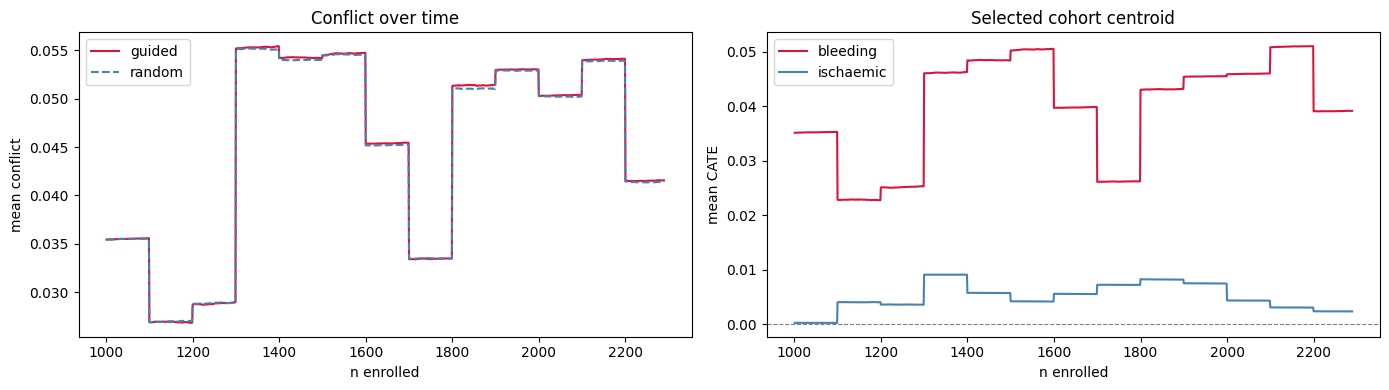

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist['n'], hist['conf_sel'], label='guided', color='crimson')
axes[0].plot(hist['n'], hist['conf_rnd'], label='random', color='steelblue', ls='--')
axes[0].set(xlabel='n enrolled', ylabel='mean conflict', title='Conflict over time')
axes[0].legend()

axes[1].plot(hist['n'], hist['centroid_bleed'], label='bleeding', color='crimson')
axes[1].plot(hist['n'], hist['centroid_isch'], label='ischaemic', color='steelblue')
axes[1].axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
axes[1].set(xlabel='n enrolled', ylabel='mean CATE', title='Selected cohort centroid')
axes[1].legend()

plt.tight_layout()
plt.show()

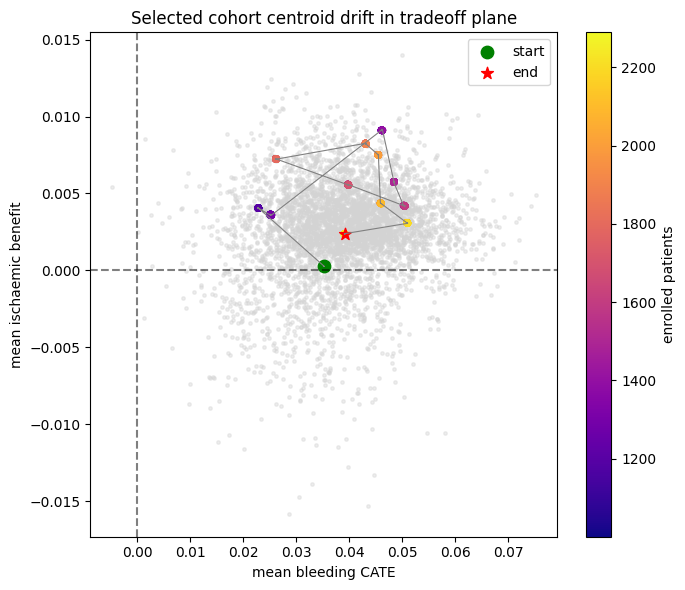

In [10]:
h = hist.dropna(subset=["centroid_bleed", "centroid_isch"])

fig, ax = plt.subplots(figsize=(7,6))

x_all = conflict["bleed"].to_numpy()
y_all = weighted_isch({k: conflict[k] for k in ISCH_WEIGHTS}, ISCH_WEIGHTS).to_numpy()
ax.scatter(x_all, y_all, s=6, color="lightgrey", alpha=0.4)

sc = ax.scatter(h["centroid_bleed"], h["centroid_isch"], c=h["n"], cmap="plasma", s=18)
ax.plot(h["centroid_bleed"], h["centroid_isch"], color="grey", lw=0.8)

ax.scatter(h["centroid_bleed"].iloc[0], h["centroid_isch"].iloc[0], s=80, color="green", label="start")
ax.scatter(h["centroid_bleed"].iloc[-1], h["centroid_isch"].iloc[-1], s=80, color="red", marker="*", label="end")

ax.axhline(0, color="k", ls="--", alpha=0.5)
ax.axvline(0, color="k", ls="--", alpha=0.5)

plt.colorbar(sc, label="enrolled patients")
ax.set_xlabel("mean bleeding CATE")
ax.set_ylabel("mean ischaemic benefit")
ax.set_title("Selected cohort centroid drift in tradeoff plane")
ax.legend()
plt.tight_layout()
plt.show()

## Results

The guided cohort steadily accumulates higher-conflict patients than random enrolment, and
on the final model's trade-off plane the enrolled points concentrate in the top-right, where
shortening the DAPT helps **both** bleeding and ischaemia — the clearest win–win patients.

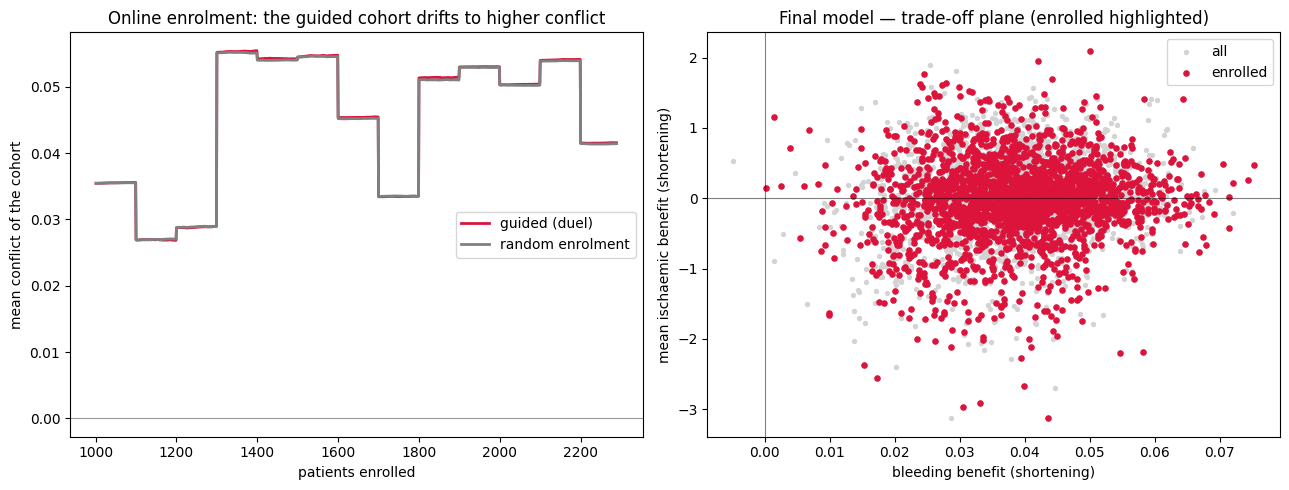

In [11]:
isch = weighted_isch({k: z(conflict[k]) for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)   # y-axis: mean ischaemic benefit
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(hist['n'], hist['conf_sel'], color='crimson', lw=2, label='guided (duel)')
ax[0].plot(hist['n'], hist['conf_rnd'], color='grey', lw=2, label='random enrolment')
ax[0].axhline(0, color='k', lw=.8, alpha=.4)
ax[0].set(xlabel='patients enrolled', ylabel='mean conflict of the cohort',
          title='Online enrolment: the guided cohort drifts to higher conflict')
ax[0].legend()

ax[1].scatter(conflict['bleed'], isch, s=8, color='lightgrey', label='all')
ax[1].scatter(conflict['bleed'].iloc[sel], isch.iloc[sel], s=14, color='crimson', label='enrolled')
ax[1].axhline(0, color='k', lw=.8, alpha=.5); ax[1].axvline(0, color='k', lw=.8, alpha=.5)
ax[1].set(xlabel='bleeding benefit (shortening)', ylabel='mean ischaemic benefit (shortening)',
          title='Final model — trade-off plane (enrolled highlighted)')
ax[1].legend()
plt.tight_layout(); plt.show()

## Where the model is least sure

`predict_cate_std` gives the forest's **standard error** on each patient's CATE (it is available
because the tuned `cf_params` carry `inference=True`), and `uncertainty_from_model` composites the
four endpoints with the *same* z-scored formula as the conflict — so the score reads on the same
scale as `conflict`: **0 = the cohort-average uncertainty**, positive = the forest is less sure
about this patient than about the typical one.

The left panel bins the trade-off plane and paints each bin by the **mean uncertainty of the
patients that fall in it** — the zones the forest cannot resolve. The right panel puts that score
against the conflict, which is the question the duel actually cares about: are the high-conflict
patients the loop chases also the ones the model is unsure about, or is the dilemma corner already
well estimated?

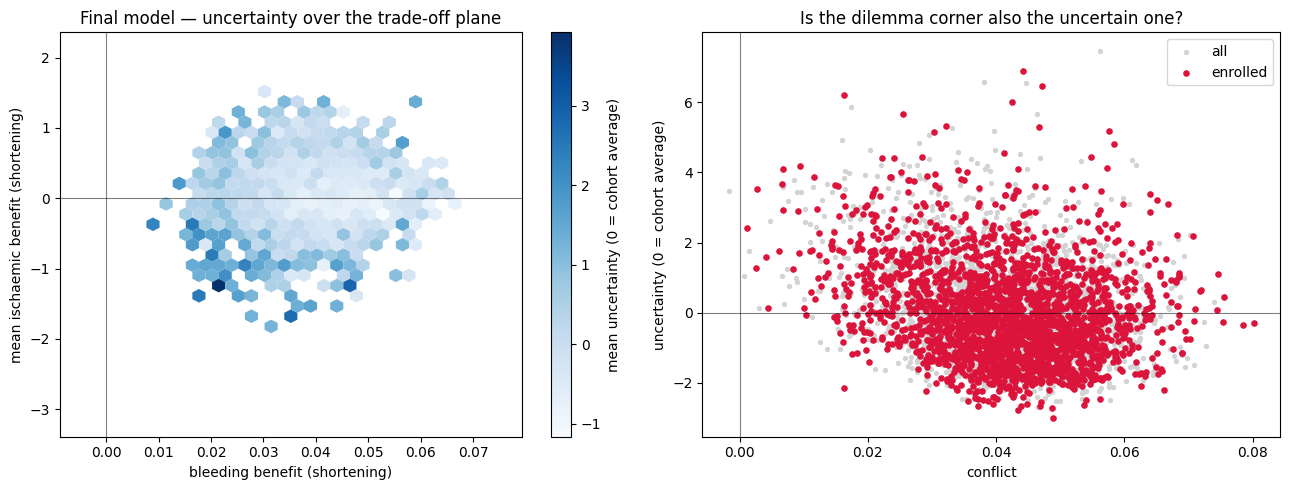

mean uncertainty   enrolled=-0.029   random=+0.012   all=-0.000


In [12]:
# Uncertainty of the FINAL model over every patient, composited exactly like the conflict.
# The plane is the same as above, so the two figures are read against each other.
unc = uncertainty_from_model(model)['uncertainty']

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# mincnt=3: a bin holding one or two patients would report that patient's noise, not a zone's.
hb = ax[0].hexbin(conflict['bleed'], isch, C=unc, reduce_C_function=np.mean,
                  gridsize=32, cmap='Blues', mincnt=3, linewidths=0)
fig.colorbar(hb, ax=ax[0], label='mean uncertainty (0 = cohort average)')
ax[0].axhline(0, color='k', lw=.8, alpha=.5); ax[0].axvline(0, color='k', lw=.8, alpha=.5)
ax[0].set(xlabel='bleeding benefit (shortening)', ylabel='mean ischaemic benefit (shortening)',
          title='Final model — uncertainty over the trade-off plane')

ax[1].scatter(conflict['conflict'], unc, s=8, color='lightgrey', label='all')
ax[1].scatter(conflict['conflict'].iloc[sel], unc.iloc[sel], s=14, color='crimson', label='enrolled')
ax[1].axhline(0, color='k', lw=.8, alpha=.5); ax[1].axvline(0, color='k', lw=.8, alpha=.5)
ax[1].set(xlabel='conflict', ylabel='uncertainty (0 = cohort average)',
          title='Is the dilemma corner also the uncertain one?')
ax[1].legend()

plt.tight_layout(); plt.show()

print(f'mean uncertainty   enrolled={unc.iloc[sel].mean():+.3f}   random={unc.iloc[rnd].mean():+.3f}   all={unc.mean():+.3f}')

## What each fit knows — the estimated gain and its spread

Each fit is a *new* estimate of the gain (the CATE) for every patient it has been given, so it can
be asked to re-score its whole history. The sweep below walks `sel[:n]` — the **actual enrolled
cohort**, seed plus every duel winner, in the true order `run_online` enrolled them — at the same
checkpoints the loop itself refit on: `N_SEED`, `N_SEED + REFIT_EVERY`, `N_SEED + 2·REFIT_EVERY`,
… up to the final cohort. This reconstructs the literal training history of the **deployed** model
— the sequence of forests that actually existed during Phase 2 — rather than an independent replay
on the raw, unfiltered arrival stream (which would also include the duel losers `run_online` never
enrolled).

The stored predictions are **ragged**: the fit at `N_SEED` patients returns `N_SEED` gains, the
final one returns `len(sel)`. That is the point. Two things are read off them: the **variance** of
the estimated gain over the patients enrolled so far, and the **drift** — how far a fit moves the
gain it had already assigned to the patients it had already seen. Prefixes nest (`sel` only grows
by appending), so the drift always compares the same patients under two successive fits.

In [13]:
# Replay the ACTUAL training history: `sel` is the real online loop's selection (seed + duel
# winners, in their true enrollment order) -- fit_cate is exactly what run_online called. At each
# REFIT_EVERY checkpoint the loop refit the model on sel[:n], so sel[:n] at those same n
# reconstructs the exact cohort the DEPLOYED model was trained on -- not an independent replay on
# the raw arrival stream (which would also include duel losers, never actually enrolled).
FIT_SIZES = list(range(N_SEED, len(sel) + 1, REFIT_EVERY))
if FIT_SIZES[-1] != len(sel):
    FIT_SIZES.append(len(sel))                          # the final state, even if not a REFIT_EVERY multiple

cate_hist = {}                                        # n -> (n x len(ONLINE_TARGETS)) CATE of the fit on sel[:n]
for n in FIT_SIZES:
    cohort = sel[:n]
    m = fit_cate(cohort, Xn, Yv, T, CausalMultiOutputPipeline, prep['cf_params'], prep['nuisance_params'])   # same params as the online loop's refits
    cate_hist[n] = m.predict_cate(Xn.values[cohort])
    print(f'fit on {n:4d} enrolled patients  ->  CATE {cate_hist[n].shape}')

# Per fit: the spread of the estimated gain, and the mean absolute correction this fit applies to
# the gains the PREVIOUS fit gave the patients it had already seen (shared leading rows, same order).
rows, prev = [], None
for n, c in cate_hist.items():
    rows.append(dict(n=n,
                     **{f'var_{k}': float(c[:, ONLINE_TARGETS.index(k)].var()) for k in ENDPOINTS},
                     drift=np.nan if prev is None else float(np.abs(c[:prev] - cate_hist[prev]).mean())*100))
    prev = n
var_hist = pd.DataFrame(rows)

fit on 1000 enrolled patients  ->  CATE (1000, 4)
fit on 1100 enrolled patients  ->  CATE (1100, 4)
fit on 1200 enrolled patients  ->  CATE (1200, 4)
fit on 1300 enrolled patients  ->  CATE (1300, 4)
fit on 1400 enrolled patients  ->  CATE (1400, 4)
fit on 1500 enrolled patients  ->  CATE (1500, 4)
fit on 1600 enrolled patients  ->  CATE (1600, 4)
fit on 1700 enrolled patients  ->  CATE (1700, 4)
fit on 1800 enrolled patients  ->  CATE (1800, 4)
fit on 1900 enrolled patients  ->  CATE (1900, 4)
fit on 2000 enrolled patients  ->  CATE (2000, 4)
fit on 2100 enrolled patients  ->  CATE (2100, 4)
fit on 2200 enrolled patients  ->  CATE (2200, 4)
fit on 2289 enrolled patients  ->  CATE (2289, 4)


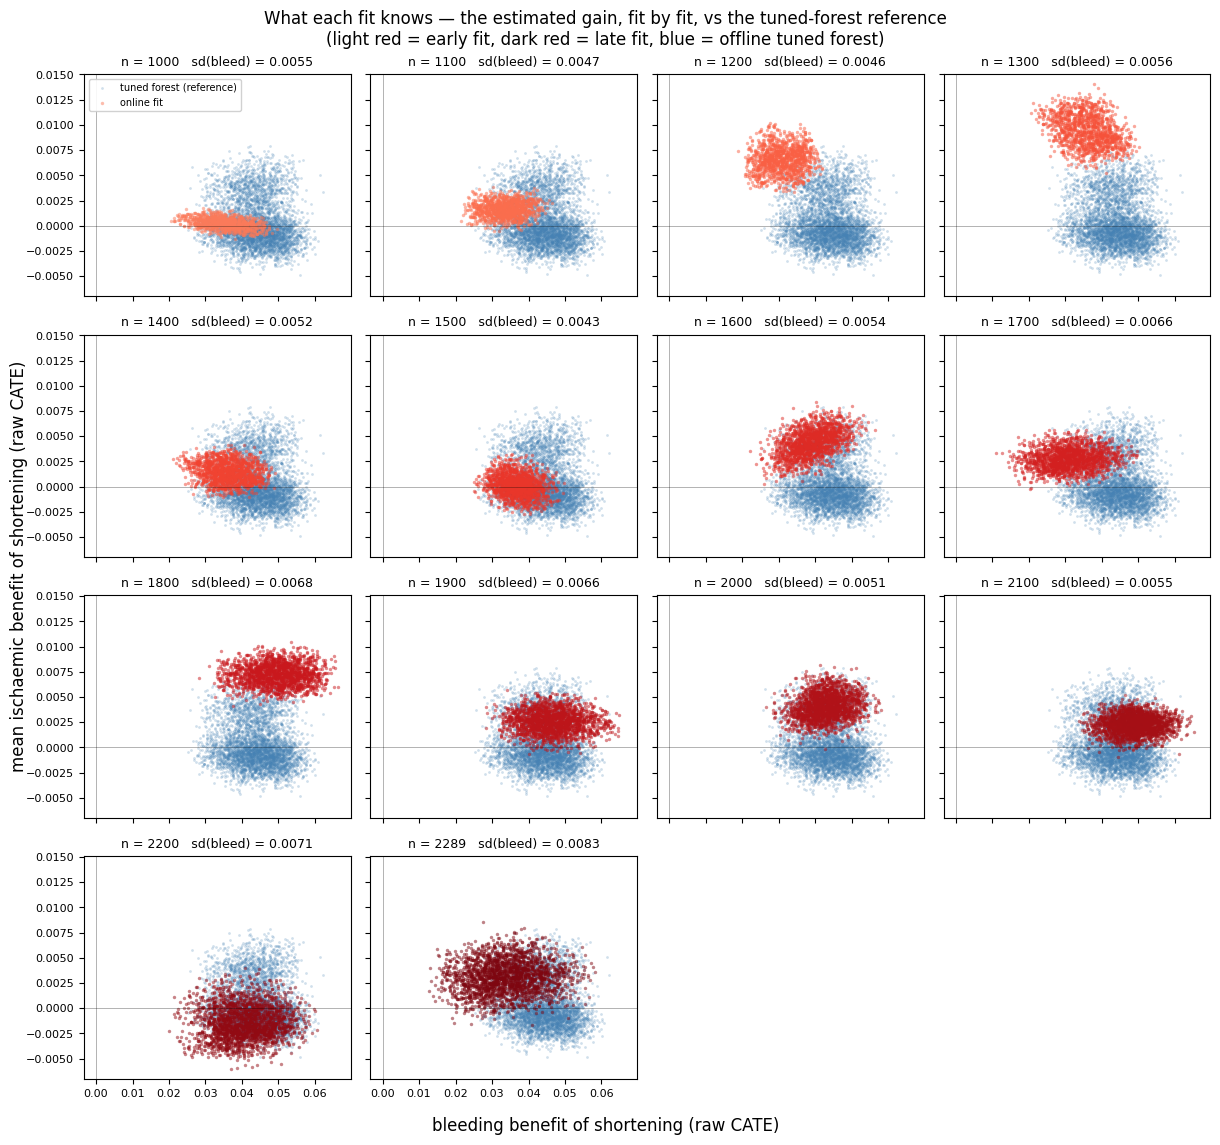

In [14]:
# The points behind the table above: each fit's estimated gain for the patients it was given,
# on the same trade-off plane as the earlier figures — one panel per fit, oldest to newest.
# The units are RAW CATE, not z-scored: `conflict` z-scores within a model, which rescales every
# cloud to unit spread and would erase exactly the collapse -> spread this figure is about.
# The axes are shared for the same reason — the panels are only comparable on one common scale.
ISCH = list(ISCH_WEIGHTS)
isch_w = np.array([ISCH_WEIGHTS[k] for k in ISCH])
weighted_mean = lambda cols: (cols * isch_w).sum(axis=1) / isch_w.sum()
plane = {n: (C[:, ONLINE_TARGETS.index('bleed')],
             weighted_mean(C[:, [ONLINE_TARGETS.index(k) for k in ISCH]]))
         for n, C in cate_hist.items()}

# Reference cloud: the offline Optuna-tuned CausalForestDML (nb 06), fitted on the FULL cohort at
# once -- same raw-CATE plane as `plane` above, so it can be drawn on every panel as the "target"
# each growing online fit is trying to approach. Loaded here (not reused from the later comparison
# section) so this cell stays self-contained.
import joblib
TUNED_PATH = os.path.normpath(os.path.join(os.getcwd(), '..', 'Meta-learning', 'models',
                                           'CausalForest', 'CausalForest_multioutput_tuned.joblib'))
CF_TARGETS = ['barc_235', 'death', 'mi', 'stroke', 'bleed']   # nb 06 TARGET_LABELS
cf_tuned   = joblib.load(TUNED_PATH)                          # CF_DIR is already on sys.path -> unpickles
cate_tuned = cf_tuned.predict_cate(Xn.values)
bx_tuned   = cate_tuned[:, CF_TARGETS.index('bleed')]
iy_tuned   = weighted_mean(cate_tuned[:, [CF_TARGETS.index(k) for k in ISCH]])

ncol = 4
nrow = int(np.ceil(len(plane) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 2.9 * nrow), sharex=True, sharey=True)
axs = np.atleast_1d(axes).ravel()
shade = plt.cm.Reds(np.linspace(0.45, 0.95, len(plane)))     # light -> dark = early -> late fit

for ax, (n, (bx, iy)), c in zip(axs, plane.items(), shade):
    ax.axhline(0, color='k', lw=.6, alpha=.35); ax.axvline(0, color='k', lw=.6, alpha=.35)
    ax.scatter(bx_tuned, iy_tuned, s=4, color='steelblue', alpha=.25, linewidths=0, label='tuned forest (reference)')
    ax.scatter(bx, iy, s=6, color=c, alpha=.5, linewidths=0, label='online fit')
    ax.set_title(f'n = {n}   sd(bleed) = {bx.std():.4f}', fontsize=9)
    ax.tick_params(labelsize=8)

for ax in axs[len(plane):]:                                  # a partly filled last row
    ax.set_visible(False)

axs[0].legend(fontsize=7, loc='upper left', framealpha=.9)
fig.suptitle('What each fit knows — the estimated gain, fit by fit, vs the tuned-forest reference\n'
            '(light red = early fit, dark red = late fit, blue = offline tuned forest)')
fig.supxlabel('bleeding benefit of shortening (raw CATE)')
fig.supylabel('mean ischaemic benefit of shortening (raw CATE)')
plt.tight_layout()
plt.show()

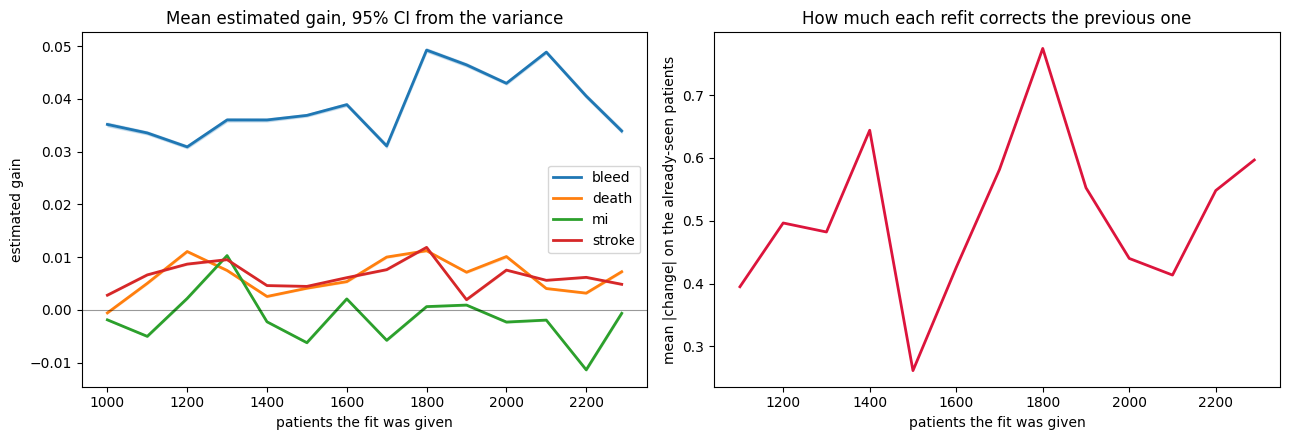

In [15]:
# The mean estimated gain with a 95% CI built from the variance tabulated above: the spread of the
# gain over the patients the fit was given, divided by how many there were -> mean +- 1.96*sqrt(var/n).
# The band narrows as the fit is given more patients, which the raw spread (a property of the
# cohort, not of the estimate) does not.
n = var_hist['n'].to_numpy()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

for k in ENDPOINTS:
    mean = np.array([cate_hist[i][:, ONLINE_TARGETS.index(k)].mean() for i in n])
    hw   = 1.96 * np.sqrt(var_hist[f'var_{k}'].to_numpy() / n)      # half-width of the CI on the mean
    line, = ax[0].plot(n, mean, lw=2, label=k)
    ax[0].fill_between(n, mean - hw, mean + hw, color=line.get_color(), alpha=.2)

ax[0].axhline(0, color='k', lw=.8, alpha=.4)
ax[0].set(xlabel='patients the fit was given', ylabel='estimated gain',
          title='Mean estimated gain, 95% CI from the variance')
ax[0].legend()

ax[1].plot(n, var_hist['drift'], color='crimson', lw=2)
ax[1].set(xlabel='patients the fit was given', ylabel='mean |change| on the already-seen patients',
          title='How much each refit corrects the previous one')

plt.tight_layout()
plt.show()


## Comparison with the offline tuned causal forest

The online forest only ever sees the patients it has enrolled. The natural benchmark is the
model nb 01 selects with: the Optuna-tuned `CausalForestDML` fitted **offline on the whole
cohort** (`CausalForest_multioutput_tuned.joblib`, nb 06) — same architecture and same AUTOC
objective, but trained on all patients at once instead of grown two at a time. Three questions:

1. **do they rank patients alike?** Spearman ρ per endpoint and on the composite conflict;
2. **do they decide alike?** replay the *same* arriving pairs through `duel_by_angle` under each
   model and count how often the winner matches — every duel has two candidates, so **50% is the
   chance floor**, not zero;
3. **does the guided cohort survive an independent referee?** the tuned model took no part in the
   online selection, so scoring the online-enrolled cohort with *its* conflict checks that the
   drift in the plot above is real and not the online forest admiring its own scores.

The tuned-guided cohort (same pairs, duelled under the tuned model) is the **ceiling** of that
referee check: it is picked with the very score it is then judged by. The gap between it and the
online-guided line is the price of having to learn the score while enrolling.

In [16]:
import joblib
from scipy.stats import spearmanr

# The offline benchmark: the Optuna-tuned CausalForestDML fitted on the FULL cohort in nb 06 —
# the model nb 01 selects with. Its CATE columns come out in nb 06's training order.
TUNED_PATH = os.path.normpath(os.path.join(os.getcwd(), '..', 'Meta-learning', 'models',
                                           'CausalForest', 'CausalForest_multioutput_tuned.joblib'))
CF_TARGETS = ['barc_235', 'death', 'mi', 'stroke', 'bleed']   # nb 06 TARGET_LABELS (as read in nb 01)

cf_tuned = joblib.load(TUNED_PATH)                            # CF_DIR is already on sys.path -> unpickles
cate_off = cf_tuned.predict_cate(Xn.values)
conflict_tuned = pd.DataFrame({k: cate_off[:, CF_TARGETS.index(k)] for k in ENDPOINTS})
conflict_tuned['conflict'] = (z(conflict_tuned['bleed'])
                              + (z(conflict_tuned['death']) + z(conflict_tuned['mi'])
                                 + z(conflict_tuned['stroke'])) / 3)          # same formula as conflict_from_model

conflict_online = conflict.copy()                             # the FINAL online model's view of every patient

print('mean CATE      ' + '  '.join(f'{k}: online={conflict_online[k].mean():+.4f}/tuned={conflict_tuned[k].mean():+.4f}'
                                    for k in ENDPOINTS))
print('\nrank agreement over all patients (Spearman rho)')
for k in list(ENDPOINTS) + ['conflict']:
    print(f'  {k:9s} rho = {spearmanr(conflict_online[k], conflict_tuned[k]).statistic:+.3f}')


def duels_under(frame, pairs, duel=duel_by_angle):
    """Replay `pairs` with `frame` standing in as the conflict view (the duel functions read
    the global `conflict`), then restore it — so this cannot disturb the online state."""
    global conflict
    saved = conflict
    conflict = frame
    try:
        return np.array([duel(int(i), int(j)) for i, j in pairs])
    finally:
        conflict = saved


# The arriving pairs the online loop actually duelled, rebuilt from the same arrival order.
pos0  = len(prep['seed_idx'])
arr   = prep['order'][pos0:pos0 + 2 * len(hist)].astype(int)
pairs = list(zip(arr[::2], arr[1::2]))

w_online = np.asarray(sel[pos0:])                       # the winners the EVOLVING online model actually kept
w_tuned  = duels_under(conflict_tuned, pairs)           # what the offline tuned model would have kept, same pairs
sel_tuned = list(prep['seed_idx']) + list(w_tuned)      # the cohort nb 01's model would have enrolled

# Only the duelled pairs are informative here: the two cohorts also share the seed by
# construction, so a whole-cohort overlap would just re-report this number diluted by it.
#print(f'\nsame duel winner on {len(pairs)} arriving pairs: {(w_online == w_tuned).mean():.1%}   (50% = chance)')

# The tuned model as an independent referee: it had no hand in the online selection.
ct = conflict_tuned['conflict']
print('\nmean conflict, scored by the TUNED model (referee)')
print(f'  online-guided cohort = {ct.iloc[sel].mean():+.3f}   (n={len(sel)})')
print(f'  tuned-guided cohort  = {ct.iloc[sel_tuned].mean():+.3f}   (n={len(sel_tuned)})   <- ceiling: judged by its own score')
print(f'  random cohort        = {ct.iloc[rnd].mean():+.3f}   (n={len(rnd)})')
print(f'  full cohort          = {ct.mean():+.3f}   (n={N})')

mean CATE      bleed: online=+0.0387/tuned=+0.0439  death: online=+0.0040/tuned=+0.0021  mi: online=-0.0072/tuned=-0.0039  stroke: online=+0.0116/tuned=+0.0036

rank agreement over all patients (Spearman rho)
  bleed     rho = +0.285
  death     rho = +0.194
  mi        rho = +0.438
  stroke    rho = +0.519
  conflict  rho = +0.224

mean conflict, scored by the TUNED model (referee)
  online-guided cohort = +0.008   (n=2289)
  tuned-guided cohort  = +0.151   (n=2289)   <- ceiling: judged by its own score
  random cohort        = -0.009   (n=2289)
  full cohort          = -0.000   (n=4579)


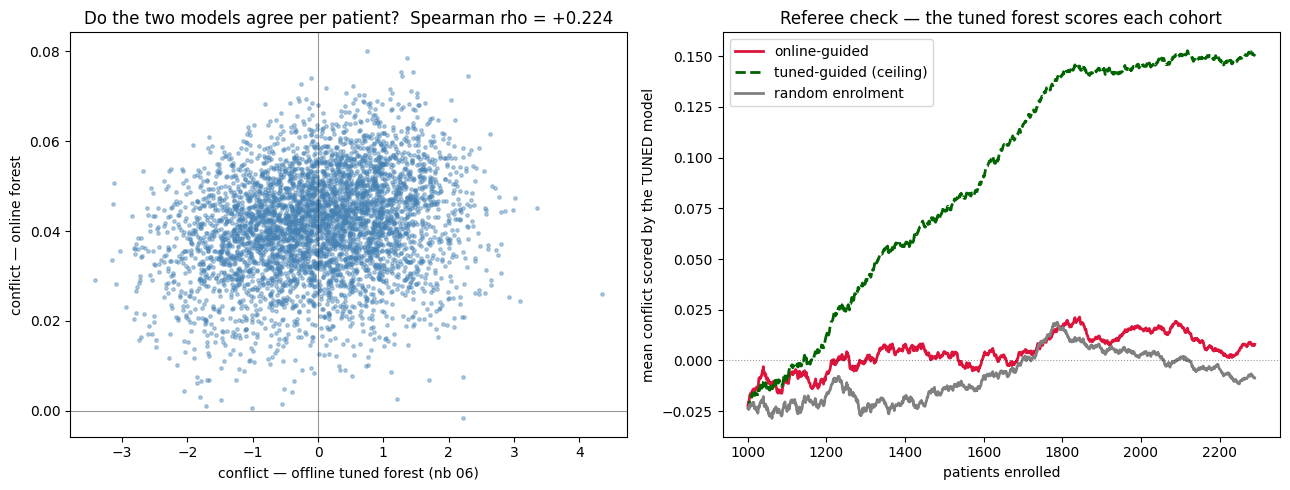

In [17]:
ns = hist['n'].to_numpy()                                  # cohort size at each step, as in the plot above
cum = lambda cohort: np.array([ct.iloc[cohort[:n]].mean() for n in ns])   # referee's view as the cohort grows

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

rho = spearmanr(conflict_online['conflict'], conflict_tuned['conflict']).statistic
ax[0].scatter(conflict_tuned['conflict'], conflict_online['conflict'], s=6, color='steelblue', alpha=.4)
ax[0].axhline(0, color='k', lw=.8, alpha=.4); ax[0].axvline(0, color='k', lw=.8, alpha=.4)
ax[0].set(xlabel='conflict — offline tuned forest (nb 06)', ylabel='conflict — online forest',
          title=f'Do the two models agree per patient?  Spearman rho = {rho:+.3f}')

ax[1].plot(ns, cum(sel),       color='crimson',  lw=2, label='online-guided')
ax[1].plot(ns, cum(sel_tuned), color='darkgreen', lw=2, ls='--', label='tuned-guided (ceiling)')
ax[1].plot(ns, cum(rnd),       color='grey',     lw=2, label='random enrolment')
ax[1].axhline(ct.mean(), color='k', lw=.8, alpha=.4, ls=':')
ax[1].set(xlabel='patients enrolled', ylabel='mean conflict scored by the TUNED model',
          title='Referee check — the tuned forest scores each cohort')
ax[1].legend()

plt.tight_layout(); plt.show()

## The decision on the held-out patients

`N_TEST` patients are held out of the arrival order by `stream_end`: never seeded, never streamed,
never fitted on, never even scored as arrivals. The final model predicts their CATE **out-of-sample**
and gives each one the arm by the **same rule the loop allocates with** — the sign of `y`, the mean
ischaemic benefit of shortening: `y > 0` → **abbreviated**, `y < 0` → **prolonged**.

The rule is applied **untempered** here. `P_FOLLOW` exists to keep the propensity inside `[0.2, 0.8]`
so the cohort the forest refits on retains both arms in every region of `X`; nothing is refit on the
test set, so there is no overlap left to protect and the honest thing to show is the rule itself,
undiluted.

`x` (the bleeding benefit) is plotted but **does not enter the decision** — the rule reads `y` alone.
The scatter therefore says how much bleeding benefit each call implicitly banks or spends: the
top-right quadrant is the unambiguous case (shortening helps bleeding *and* ischaemia, nothing to
trade), while abbreviated calls sitting left of `x = 0` are patients the rule shortens *despite* an
expected bleeding cost, because their ischaemic side came out favourable.

training rule  (|conflict| exploitation)       abbreviated= 500  prolonged= 500  abbrev. w/ negative ischaemic benefit=32
original policy  (duel_by_angle, p_unc=0)      abbreviated= 500  prolonged= 500  abbrev. w/ negative ischaemic benefit=109


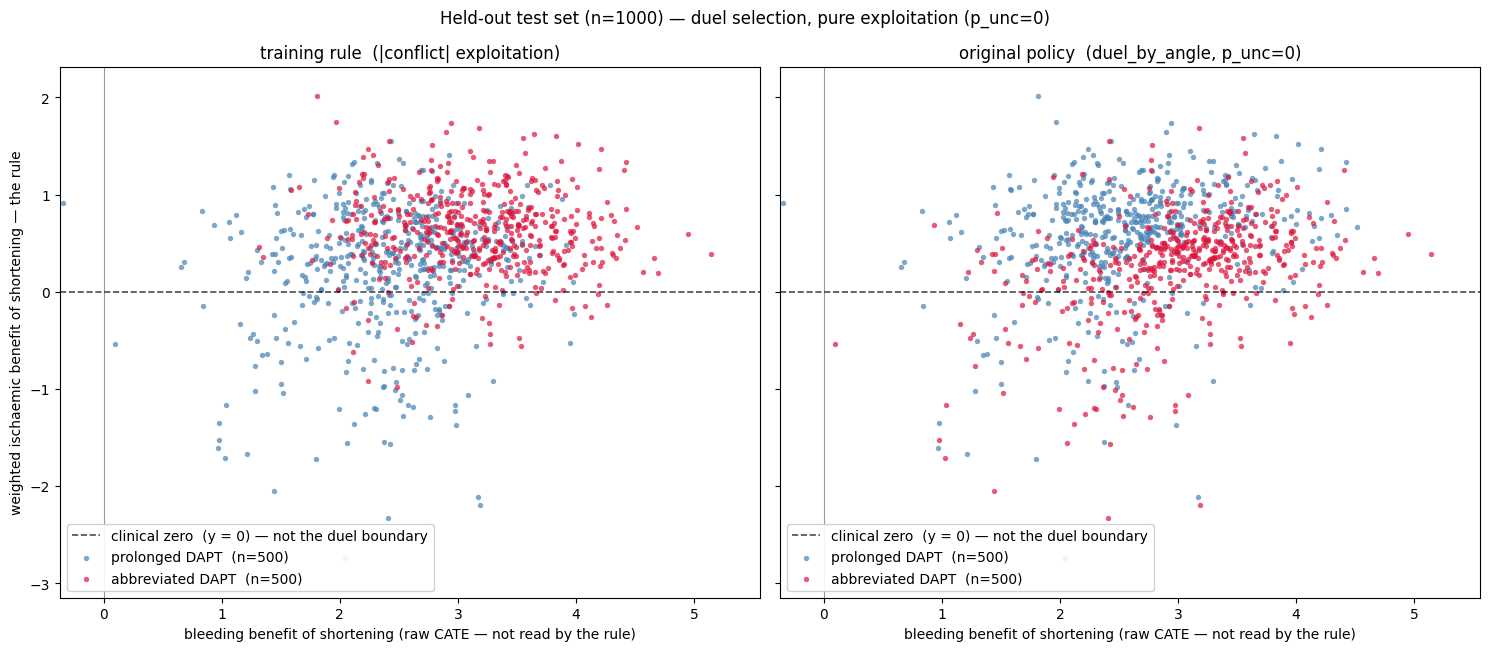

In [18]:
test      = np.asarray(prep['test_idx'])
cate_test = model.predict_cate(Xn.values[test])

conflict_test    = conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS).iloc[test].reset_index(drop=True)
uncertainty_test = uncertainty_from_model(model).iloc[test].reset_index(drop=True)

# point globals so _conf / _unc / duel_by_angle / policy read from the test frames
conflict    = conflict_test
uncertainty = uncertainty_test

# helpers usati da OPTION A (erano definiti nel vecchio loop select_pair, ora rimosso)
def _conf(i): return abs(float(conflict['conflict'].iloc[i]))
def _unc(i):  return float(np.mean(np.asarray(uncertainty)[i]))   # scalar (mean across endpoints)

# plane=False: RAW, uncentred coordinates. These feed the scatter and the `iy < 0`
# diagnostics below, where y = 0 has to keep meaning "no ischaemic benefit" (the
# clinical zero) rather than "below the cohort median". The DUELS use the centred
# decision plane instead -- duel_by_angle gets it from components_from_origin's
# default -- so the boundary the rule applies is NOT the line drawn at y = 0 here.
xy     = [components_from_origin(k, conflict_test, ISCH_WEIGHTS, plane=False) for k in range(len(test))]
bx, iy = map(np.array, zip(*xy))

# point globals so _conf / _unc / duel_by_angle / policy read from the test frames
conflict    = conflict_test
uncertainty = uncertainty_test


def run_selection(select):
    """Pair up shuffled test patients; `select(i, j, rng)` returns the duel winners. Fixed seed."""
    rng = np.random.default_rng(42)
    idx = np.arange(len(conflict_test)); rng.shuffle(idx)
    abbreviated, prolonged = [], []
    for k in range(0, len(idx) - 1, 2):
        i, j    = int(idx[k]), int(idx[k + 1])
        winners = select(i, j, rng)
        abbreviated.extend(winners)
        prolonged.extend([p for p in (i, j) if p not in winners])
    return np.asarray(abbreviated, dtype=int), np.asarray(prolonged, dtype=int)


# --- OPTION A: same rule as training — pure exploitation on |conflict|, single winner ---
def select_training(i, j, rng):
    return [i if _conf(i) >= _conf(j) else j]

# --- OPTION B: the original policy from online_learning_utils (p_unc=0), full signature ---
def select_policy(i, j, rng):
    winner, _ = policy(i, j, n_added=0, rng=rng,
                       uncertainty=uncertainty_test,
                       duel=duel_by_angle,
                       p_unc=0)
    return [winner]


options = [('training rule  (|conflict| exploitation)', select_training),
           ('original policy  (duel_by_angle, p_unc=0)', select_policy)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.6), sharex=True, sharey=True)
for ax, (name, select_fn) in zip(axes, options):
    abbreviated, prolonged = run_selection(select_fn)
    ax.axhline(0, color='k', lw=1.2, ls='--', alpha=.7, label='clinical zero  (y = 0) — not the duel boundary')
    ax.scatter(bx[prolonged],   iy[prolonged],   s=15, color='steelblue', alpha=.7, linewidths=0,
               label=f'prolonged DAPT  (n={len(prolonged)})')
    ax.scatter(bx[abbreviated], iy[abbreviated], s=15, color='crimson',   alpha=.7, linewidths=0,
               label=f'abbreviated DAPT  (n={len(abbreviated)})')
    ax.axvline(0, color='k', lw=.8, alpha=.4)
    ax.set(xlabel='bleeding benefit of shortening (raw CATE — not read by the rule)', title=name)
    ax.legend(loc='lower left', framealpha=.9)
    print(f'{name:45s}  abbreviated={len(abbreviated):4d}  prolonged={len(prolonged):4d}  '
          f'abbrev. w/ negative ischaemic benefit={int((iy[abbreviated] < 0).sum())}')

axes[0].set_ylabel('weighted ischaemic benefit of shortening — the rule')
axes[0].set_xlim(bx.min() * 1.08, bx.max() * 1.08)
axes[0].set_ylim(iy.min() * 1.15, iy.max() * 1.15)
fig.suptitle(f'Held-out test set (n={len(test)}) — duel selection, pure exploitation (p_unc=0)')
plt.tight_layout()
plt.show()


training |conflict|
abbreviated=500, prolonged=500
abbrev with iy<0: 32 (6.4%)
prolonged with iy>0: 364 (72.8%)

training + ischemic gate
abbreviated=500, prolonged=500
abbrev with iy<0: 17 (3.4%)
prolonged with iy>0: 349 (69.8%)

duel_by_angle
abbreviated=500, prolonged=500
abbrev with iy<0: 109 (21.8%)
prolonged with iy>0: 441 (88.2%)

perfect rule (oracle)
abbreviated=832, prolonged=168
abbrev with iy<0: 0
prolonged with iy>0: 0


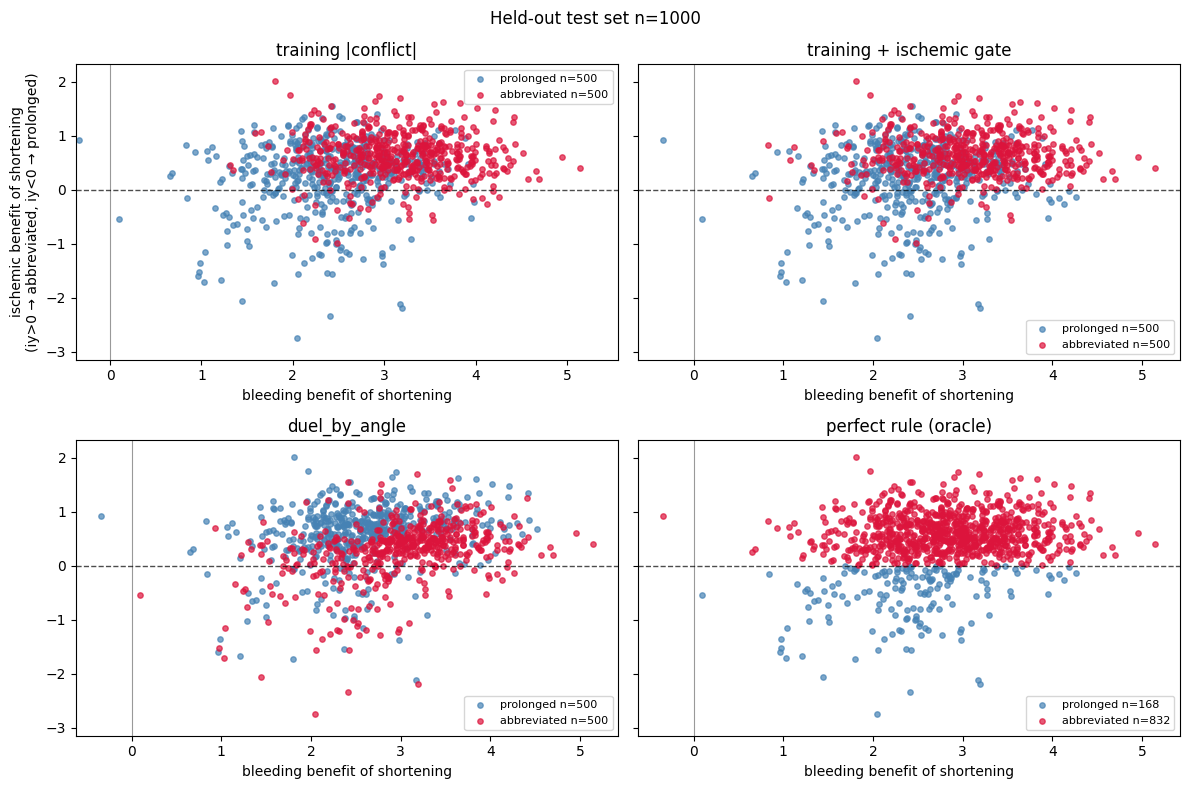

In [19]:
dtest=np.asarray(prep['test_idx'])
cate_test=model.predict_cate(Xn.values[test])

conflict_test=conflict_from_model(model,Xn,ENDPOINTS,ISCH_WEIGHTS,ONLINE_TARGETS).iloc[test].reset_index(drop=True)
uncertainty_test=uncertainty_from_model(model).iloc[test].reset_index(drop=True)

conflict=conflict_test
uncertainty=uncertainty_test

def _conf(i): return abs(float(conflict['conflict'].iloc[i]))
def _unc(i): return float(np.mean(np.asarray(uncertainty)[i]))

# plane=False -> raw units: `select_training_gated` gates on iy > 0 as a CLINICAL test
# ("does shortening help this patient on ischaemia at all"), which only holds on the
# uncentred axis. duel_by_angle keeps using the centred decision plane.
xy=[components_from_origin(k,conflict_test,ISCH_WEIGHTS,plane=False) for k in range(len(test))]
bx,iy=map(np.array,zip(*xy))


def run_selection(select):
    rng=np.random.default_rng(42)
    idx=np.arange(len(conflict_test)); rng.shuffle(idx)
    abbreviated,prolonged=[],[]
    for k in range(0,len(idx)-1,2):
        i,j=int(idx[k]),int(idx[k+1])
        winners=select(i,j,rng)
        abbreviated.extend(winners)
        prolonged.extend([p for p in (i,j) if p not in winners])
    return np.asarray(abbreviated),np.asarray(prolonged)


# |conflict| exploitation (original training rule)
def select_training(i,j,rng):
    return [i if _conf(i)>=_conf(j) else j]

"""
# gated by ischemic sign:
# iy>0 -> abbreviated
# iy<0 -> prolonged
def select_training_gated(i,j,rng):
    candidates=[p for p in (i,j) if iy[p]>0]
    return [max(candidates,key=_conf)] if candidates else []
"""

def select_training_gated(i,j,rng):

    if iy[i] > 0 and iy[j] > 0:
        return [max([i,j],key=_conf)]

    if iy[i] > 0 and iy[j] <= 0:
        return [i]

    if iy[j] > 0 and iy[i] <= 0:
        return [j]

    return [i if iy[i] > iy[j] else j]


# original policy
def select_policy(i,j,rng):
    winner,_=policy(i,j,n_added=0,rng=rng,
                    uncertainty=uncertainty_test,
                    duel=duel_by_angle,
                    p_unc=0)
    return [winner]


options=[
    ('training |conflict|',select_training),
    ('training + ischemic gate',select_training_gated),
    ('duel_by_angle',select_policy)
]


fig,axes=plt.subplots(2,2,figsize=(12,8),sharey=True)
axes=axes.ravel()


# --- plot delle tre strategie ---
for ax,(name,fn) in zip(axes[:3],options):

    abbreviated,prolonged=run_selection(fn)

    ax.axhline(0,color='k',lw=1,ls='--',alpha=.7)

    ax.scatter(bx[prolonged],iy[prolonged],
               s=15,color='steelblue',
               alpha=.7,label=f'prolonged n={len(prolonged)}')

    ax.scatter(bx[abbreviated],iy[abbreviated],
               s=15,color='crimson',
               alpha=.7,label=f'abbreviated n={len(abbreviated)}')

    ax.axvline(0,color='k',lw=.8,alpha=.4)

    ax.set_title(name)
    ax.set_xlabel('bleeding benefit of shortening')
    ax.legend(fontsize=8)

    wrong_a=(iy[abbreviated]<0).sum()
    wrong_p=(iy[prolonged]>0).sum()

    print(f'\n{name}')
    print(f'abbreviated={len(abbreviated)}, prolonged={len(prolonged)}')
    print(f'abbrev with iy<0: {wrong_a} ({100*wrong_a/max(len(abbreviated),1):.1f}%)')
    print(f'prolonged with iy>0: {wrong_p} ({100*wrong_p/max(len(prolonged),1):.1f}%)')


perfect_abbreviated=np.where(iy>0)[0]
perfect_prolonged=np.where(iy<0)[0]

ax=axes[3]

ax.axhline(0,color='k',lw=1,ls='--',alpha=.7)

ax.scatter(bx[perfect_prolonged],iy[perfect_prolonged],
           s=15,color='steelblue',
           alpha=.7,
           label=f'prolonged n={len(perfect_prolonged)}')

ax.scatter(bx[perfect_abbreviated],iy[perfect_abbreviated],
           s=15,color='crimson',
           alpha=.7,
           label=f'abbreviated n={len(perfect_abbreviated)}')

ax.axvline(0,color='k',lw=.8,alpha=.4)

ax.set_title('perfect rule (oracle)')
ax.set_xlabel('bleeding benefit of shortening')
ax.legend(fontsize=8)


# errori della regola perfetta
wrong_a=(iy[perfect_abbreviated]<0).sum()
wrong_p=(iy[perfect_prolonged]>0).sum()

print('\nperfect rule (oracle)')
print(f'abbreviated={len(perfect_abbreviated)}, prolonged={len(perfect_prolonged)}')
print(f'abbrev with iy<0: {wrong_a}')
print(f'prolonged with iy>0: {wrong_p}')


axes[0].set_ylabel(
    'ischemic benefit of shortening\n(iy>0 → abbreviated, iy<0 → prolonged)'
)

axes[0].set_xlim(bx.min()*1.08,bx.max()*1.08)
axes[0].set_ylim(iy.min()*1.15,iy.max()*1.15)

plt.suptitle(f'Held-out test set n={len(test)}')
plt.tight_layout()
plt.show()

## Observed MI / stroke rate — abbreviated vs the rest of the test set

Not a model prediction: the **real, recorded** MI (`cec_mi_335d`) and stroke (`cec_stroke_335d`)
outcomes of the held-out patients, split by the arm the rule just gave them above (`abbreviated` /
`prolonged`, the duel winners on the shuffled test pairs). "the rest" = the prolonged group within
this **same test set**, not the whole cohort. `abbreviated` / `prolonged` are LOCAL indices into
`test` (0..len(test)-1, built from `conflict_test`), so they are mapped back to global patient rows
via `test[...]` before touching `y`. Death is left out of the composite — it already has its own
weight in the conflict score above; this asks specifically about MI-or-stroke.

=== training rule (|conflict|) ===
                n           MI       stroke MI or stroke         bleed
abbreviated   500  3.0% ± 1.5%  0.0% ± 0.0%  3.0% ± 1.5%  10.6% ± 2.7%
prolonged     500  2.6% ± 1.4%  1.0% ± 0.9%  3.6% ± 1.6%  10.2% ± 2.7%
all (test)   1000  2.8% ± 1.0%  0.5% ± 0.4%  3.3% ± 1.1%  10.4% ± 1.9%
ischaemic RR=0.83  OR=0.83  Fisher p=0.724
bleeding  RR=1.04  OR=1.04  Fisher p=0.918
n abbreviated=500, prolonged=500

=== training + ischemic gate ===
                n           MI       stroke MI or stroke         bleed
abbreviated   483  2.7% ± 1.4%  0.0% ± 0.0%  2.7% ± 1.4%  11.2% ± 2.8%
prolonged     517  2.9% ± 1.4%  1.0% ± 0.8%  3.9% ± 1.7%   9.7% ± 2.5%
all (test)   1000  2.8% ± 1.0%  0.5% ± 0.4%  3.3% ± 1.1%  10.4% ± 1.9%
ischaemic RR=0.70  OR=0.69  Fisher p=0.376
bleeding  RR=1.16  OR=1.18  Fisher p=0.469
n abbreviated=483, prolonged=517

=== original policy (duel_by_angle) ===
                n           MI       stroke MI or stroke         bleed
abbreviated  

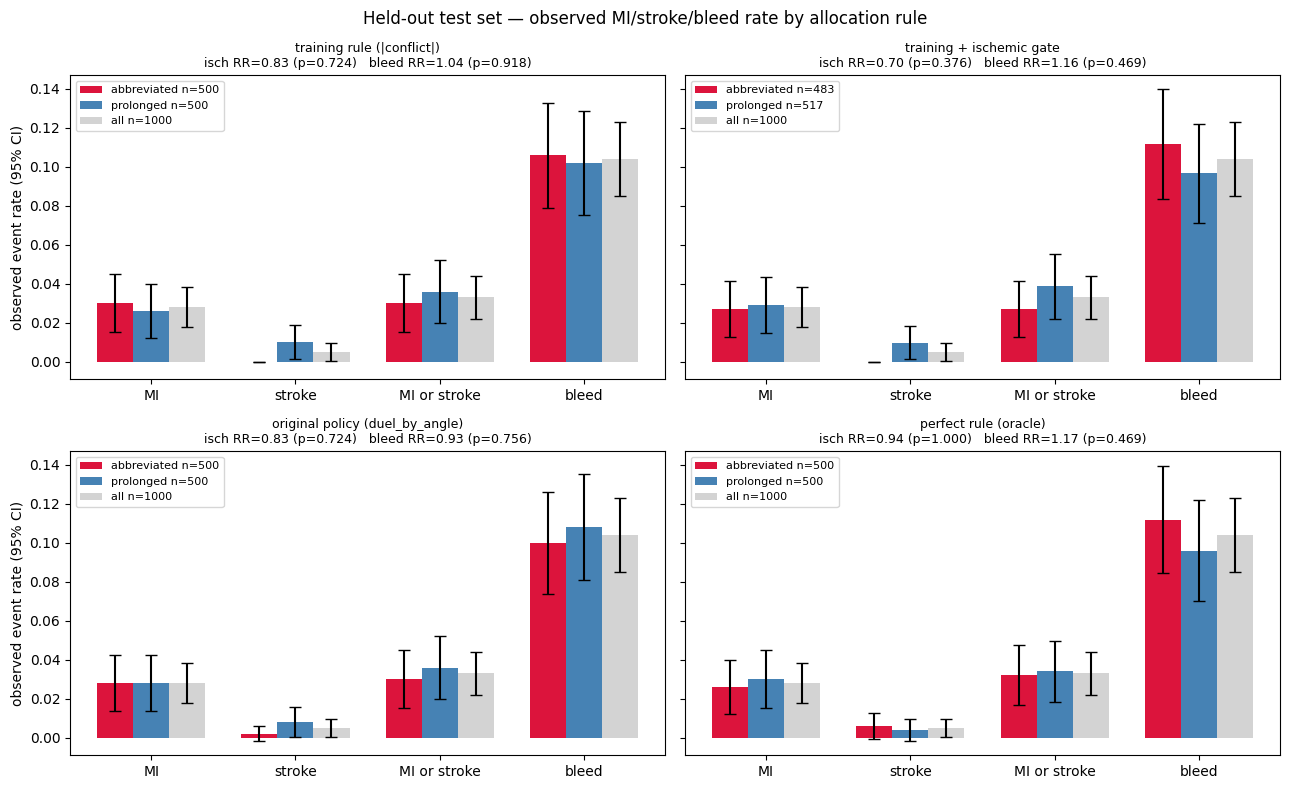

In [20]:
from scipy.stats import fisher_exact

y_mi=y[ENDPOINTS['mi']].to_numpy()
y_stroke=y[ENDPOINTS['stroke']].to_numpy()
y_bleed=y[ENDPOINTS['bleed']].to_numpy()
y_combo=((y_mi==1)|(y_stroke==1)).astype(int)

def rate_ci(idx,event):
    n=len(idx); p=event[idx].mean()
    return p,1.96*np.sqrt(p*(1-p)/n),n

def analyse(abbreviated,prolonged):
    test_abbrev=test[abbreviated]
    test_prolonged=test[prolonged]
    combo=np.concatenate([test_abbrev,test_prolonged])

    groups={
        'abbreviated':test_abbrev,
        'prolonged':test_prolonged,
        'all (test)':combo
    }

    table=pd.DataFrame({
        label:{
            ev_name:f'{p:.1%} ± {hw:.1%}'
            for ev_name,ev in [('MI',y_mi),('stroke',y_stroke),('MI or stroke',y_combo),('bleed',y_bleed)]
            for p,hw,_ in [rate_ci(idx,ev)]
        }
        for label,idx in groups.items()
    }).T

    table.insert(0,'n',[len(idx) for idx in groups.values()])

    a_n=len(test_abbrev)
    p_n=len(test_prolonged)

    # ischaemic RR (MI or stroke)
    a_ev=int(y_combo[test_abbrev].sum())
    p_ev=int(y_combo[test_prolonged].sum())
    rr=(a_ev/a_n)/(p_ev/p_n) if p_ev else np.nan
    odds,pval=fisher_exact([[a_ev,a_n-a_ev],[p_ev,p_n-p_ev]])

    # bleeding RR
    a_bl=int(y_bleed[test_abbrev].sum())
    p_bl=int(y_bleed[test_prolonged].sum())
    rr_bleed=(a_bl/a_n)/(p_bl/p_n) if p_bl else np.nan
    odds_bleed,pval_bleed=fisher_exact([[a_bl,a_n-a_bl],[p_bl,p_n-p_bl]])

    return dict(
        table=table,
        combo=combo,
        test_abbrev=test_abbrev,
        test_prolonged=test_prolonged,
        rr=rr,
        odds=odds,
        pval=pval,
        rr_bleed=rr_bleed,
        odds_bleed=odds_bleed,
        pval_bleed=pval_bleed
    )


def select_training(i,j,rng):
    return [i if _conf(i)>=_conf(j) else j]

def select_training_gated(i,j,rng):
    candidates=[p for p in (i,j) if iy[p]>0]
    return [max(candidates,key=_conf)] if candidates else []

def select_policy(i,j,rng):
    winner,_=policy(
        i,j,
        n_added=0,
        rng=rng,
        uncertainty=uncertainty_test,
        duel=duel_by_angle,
        p_unc=0
    )
    return [winner]

def select_perfect(i,j,rng):
    if iy[i]>0 and iy[j]>0:
        return [i if iy[i]>=iy[j] else j]
    if iy[i]>0:
        return [i]
    if iy[j]>0:
        return [j]
    return [i if iy[i]<=iy[j] else j]


options=[
    ('training rule (|conflict|)',select_training),
    ('training + ischemic gate',select_training_gated),
    ('original policy (duel_by_angle)',select_policy),
    ('perfect rule (oracle)',select_perfect)
]

results={name:analyse(*run_selection(sel)) for name,sel in options}

for name,r in results.items():
    print(f'=== {name} ===')
    print(r['table'].to_string())
    print(f"ischaemic RR={r['rr']:.2f}  OR={r['odds']:.2f}  Fisher p={r['pval']:.3f}")
    print(f"bleeding  RR={r['rr_bleed']:.2f}  OR={r['odds_bleed']:.2f}  Fisher p={r['pval_bleed']:.3f}")
    print(f"n abbreviated={len(r['test_abbrev'])}, prolonged={len(r['test_prolonged'])}\n")


labels=['MI','stroke','MI or stroke','bleed']
events=[y_mi,y_stroke,y_combo,y_bleed]

xpos=np.arange(len(labels))
w=.25

fig,axes=plt.subplots(2,2,figsize=(13,8),sharey=True)
axes=axes.ravel()

for ax,(name,r) in zip(axes,results.items()):
    ta,tp,cb=r['test_abbrev'],r['test_prolonged'],r['combo']

    p_ab,hw_ab=zip(*[rate_ci(ta,e)[:2] for e in events])
    p_pr,hw_pr=zip(*[rate_ci(tp,e)[:2] for e in events])
    p_all,hw_all=zip(*[rate_ci(cb,e)[:2] for e in events])

    ax.bar(xpos-w,p_ab,width=w,yerr=hw_ab,color='crimson',capsize=4,label=f'abbreviated n={len(ta)}')
    ax.bar(xpos,p_pr,width=w,yerr=hw_pr,color='steelblue',capsize=4,label=f'prolonged n={len(tp)}')
    ax.bar(xpos+w,p_all,width=w,yerr=hw_all,color='lightgray',capsize=4,label=f'all n={len(cb)}')

    ax.set_xticks(xpos)
    ax.set_xticklabels(labels)
    ax.set_title(f"{name}\nisch RR={r['rr']:.2f} (p={r['pval']:.3f})   bleed RR={r['rr_bleed']:.2f} (p={r['pval_bleed']:.3f})",
                 fontsize=9)
    ax.legend(fontsize=8)

axes[0].set_ylabel('observed event rate (95% CI)')
axes[2].set_ylabel('observed event rate (95% CI)')
fig.suptitle('Held-out test set — observed MI/stroke/bleed rate by allocation rule')
plt.tight_layout()
plt.show()

# todo change name of the perfect rule

## The same held-out patients, judged by the tuned forest

The held-out patients are the one place the online model can be read honestly — it never fitted on
them — so this is where its inferences are worth putting against the tuned benchmark: the Optuna-tuned
`CausalForestDML` from nb 06 already loaded above as `conflict_tuned`. Same architecture, same AUTOC
objective; the difference is that it was fitted on the whole cohort at once, while the online forest
was grown from a stream whose other half the allocation had to throw away.

The comparison is made on **`y`** — the mean ischaemic benefit of shortening, the axis the allocation
rule actually reads — and then on the thing that matters, whether the two models **call the same arm**
for the same patient. Rank agreement per endpoint is reported alongside, so a disagreement on the
decision can be traced to which endpoint the two forests order differently.

**This is a benchmark, not a referee.** nb 06 fitted that forest on the *full* cohort, so these
held-out patients are **in-sample for it** while they are out-of-sample for the online model. It
judges them with an advantage. A disagreement therefore does not convict the online forest, and the
rho is not a test of who is right — what it measures is whether a model grown online from half a
stream arrives at the same view as one handed every patient at once. (The earlier referee check runs
the other way and stays valid: the tuned model took no part in the online *selection*.)

Read the abbreviated rates before the agreement rate. If the online CATE has collapsed towards a
constant — which the variance table above will say — its `y` barely crosses zero, the arm split
degenerates to one side, and both the rho and the agreement stop carrying information.

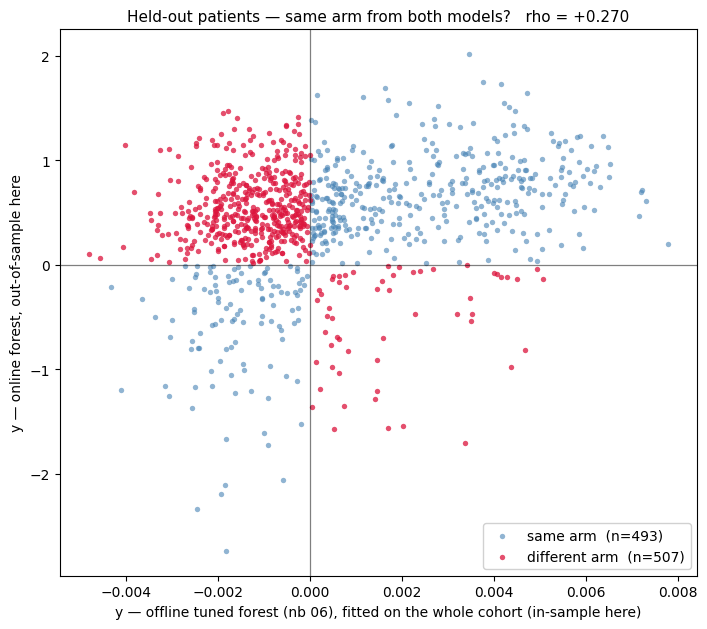

test-set rank agreement, online vs tuned (Spearman rho)
  bleed     rho = +0.237
  death     rho = +0.139
  mi        rho = +0.466
  stroke    rho = +0.527
  y (rule)  rho = +0.270

same arm on 1000 held-out patients: 49.3%   (expected from the marginals alone = 45.8%)
  spread of y   online sd=0.58494   tuned sd=0.00239


In [21]:
# The tuned forest's view of the SAME held-out patients, on the same raw axis the rule reads.
# Weight the endpoints exactly like the online rule (death 0.2 / mi 0.4 / stroke 0.4).
y_tuned     = (conflict_tuned['death'] * 0.2 + conflict_tuned['mi'] * 0.4
               + conflict_tuned['stroke'] * 0.4).to_numpy()[test]
short_tuned = y_tuned > 0                                # the arm the TUNED forest's y would give
short       = iy > 0                                     # the arm the ONLINE forest's y gives (was dropped)

agree  = short == short_tuned
chance = short.mean() * short_tuned.mean() + (1 - short.mean()) * (1 - short_tuned.mean())
rho_y  = spearmanr(iy, y_tuned).statistic

fig, ax = plt.subplots(figsize=(7.2, 6.4))
ax.scatter(y_tuned[agree],  iy[agree],  s=15, color='steelblue', alpha=.6,  linewidths=0,
           label=f'same arm  (n={int(agree.sum())})')
ax.scatter(y_tuned[~agree], iy[~agree], s=15, color='crimson',   alpha=.75, linewidths=0,
           label=f'different arm  (n={int((~agree).sum())})')
ax.axhline(0, color='k', lw=.9, alpha=.5); ax.axvline(0, color='k', lw=.9, alpha=.5)
ax.set(xlabel='y — offline tuned forest (nb 06), fitted on the whole cohort (in-sample here)',
       ylabel='y — online forest, out-of-sample here',
       title=f'Held-out patients — same arm from both models?   rho = {rho_y:+.3f}')
ax.title.set_fontsize(11)
ax.legend(loc='lower right', framealpha=.9)
plt.tight_layout(); plt.show()

print('test-set rank agreement, online vs tuned (Spearman rho)')
for k in ENDPOINTS:
    r = spearmanr(cate_test[:, ONLINE_TARGETS.index(k)], conflict_tuned[k].to_numpy()[test]).statistic
    print(f'  {k:9s} rho = {r:+.3f}')
print(f'  {"y (rule)":9s} rho = {rho_y:+.3f}')

print(f'\nsame arm on {len(test)} held-out patients: {agree.mean():.1%}   '
      f'(expected from the marginals alone = {chance:.1%})')
print(f'  spread of y   online sd={iy.std():.5f}   tuned sd={y_tuned.std():.5f}')

## Inference — enrolment status as the arm

A last, simpler read of the same run: instead of a model rule, colour every patient the loop
touched by what actually happened to it in the duel.

- **enrolled** — a duel winner the growing cohort kept (`sel`, minus the seed) → drawn as the
  **short (abbreviated)** arm;
- **unenrolled** — a duel loser, seen but discarded at the pairwise stage (`unenrolled`) → drawn
  as the **long (prolonged)** arm;
- **seed (initial)** — the first `N_SEED` patients, given directly with their own trial arm
  before any duel existed → its own colour, kept apart from the two above.

This is a labelling of enrolment status, not the model's `assign_arm` rule — it says where each
group of patients sits on the final trade-off plane, not what arm the forest would actually give
them. `assign_arm` now runs in `run_online` above (rejection sampling is live): a duel winner
whose trial arm disagreed with it is dropped via `continue` before either list is updated, so that
patient — and the opponent it beat — end up in neither `enrolled` nor `unenrolled` and are simply
absent from this plot, not folded into one of the two colours.

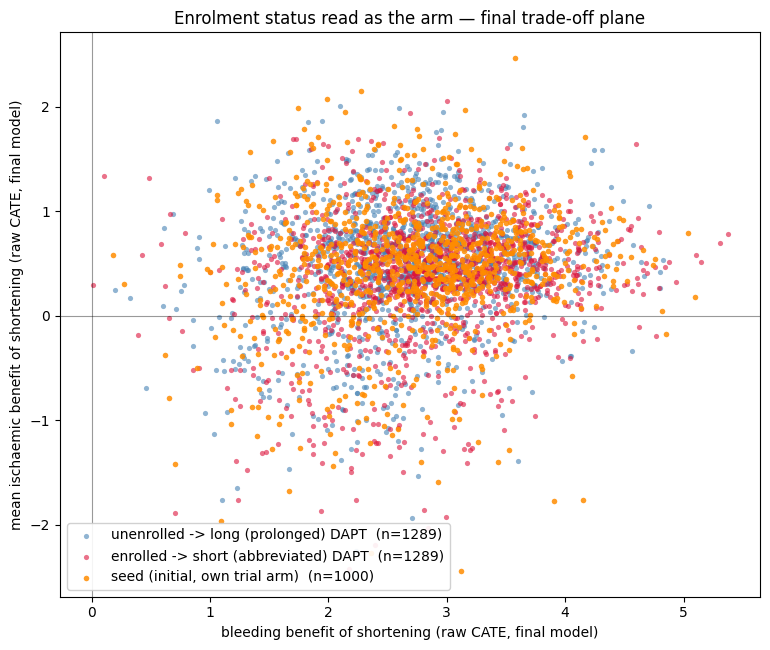

In [22]:
conflict = conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)

seed_idx       = np.asarray(prep['seed_idx'], dtype=int)
sel_arr        = np.asarray(sel, dtype=int)
enrolled_idx   = sel_arr[len(seed_idx):]              # online enrolments (tail after the seed)
unenrolled_idx = np.asarray(unenrolled, dtype=int)

x      = conflict['bleed'].to_numpy()
y_isch = weighted_isch({k: conflict[k] for k in ISCH_WEIGHTS}, ISCH_WEIGHTS).to_numpy()

fig, ax = plt.subplots(figsize=(7.8, 6.6))
ax.axhline(0, color='k', lw=.8, alpha=.4); ax.axvline(0, color='k', lw=.8, alpha=.4)
ax.scatter(x[unenrolled_idx], y_isch[unenrolled_idx], s=14, color='steelblue', alpha=.6, linewidths=0,
           label=f'unenrolled -> long (prolonged) DAPT  (n={len(unenrolled_idx)})')
ax.scatter(x[enrolled_idx], y_isch[enrolled_idx], s=14, color='crimson', alpha=.6, linewidths=0,
           label=f'enrolled -> short (abbreviated) DAPT  (n={len(enrolled_idx)})')
ax.scatter(x[seed_idx], y_isch[seed_idx], s=16, color='darkorange', alpha=.85, linewidths=0,
           label=f'seed (initial, own trial arm)  (n={len(seed_idx)})')
ax.set(xlabel='bleeding benefit of shortening (raw CATE, final model)',
       ylabel='mean ischaemic benefit of shortening (raw CATE, final model)',
       title='Enrolment status read as the arm — final trade-off plane')
ax.legend(loc='lower left', framealpha=.9)
plt.tight_layout(); plt.show()

## Net-benefit variant — trade-off-seeking selection instead of win-win

Everything above enrols by `duel_by_angle`, which targets the win-win diagonal: `conflict`
(`conflict_from_model`, `bleed + weighted_isch`) is large-positive when shortening helps
**both** bleeding and ischaemia. This section swaps the operative score for
`net_benefit_from_model` (`bleed - weighted_isch`, `online_learning_utils.py`) and a duel that
exploits it directly — high `net_benefit` means shortening helps bleeding a lot while it
*hurts* ischaemia (the bottom-right trade-off corner nb 10 calls `conflict`), the opposite of
what the run above was built to find.

Same seed, same architecture, same phase-2 mechanics (`run_online`, `policy`) as the original
run: only the score the duel reads is different, so the two enrolled cohorts are directly
comparable at the same `n`.

In [23]:
from online_learning_utils import net_benefit_from_model


def duel_by_net_benefit(i, j):
    """Pure exploitation of the trade-off score: keep the higher `net_benefit` (bleed -
    weighted_isch). Ties go to j, matching online_learning_utils.duel_by_conflict."""
    v1 = net_benefit_frame['net_benefit'].iloc[i]
    v2 = net_benefit_frame['net_benefit'].iloc[j]
    return i if v1 > v2 else j


def run_online_net_benefit(prep, n_steps, duel=duel_by_net_benefit, n_trials_final=0,
                            scale_net_benefit=True, refit_trials=0):
    """PHASE 2 -- identical to `run_online` above, but scored by `net_benefit_from_model`
    (the trade-off score) instead of `conflict_from_model` (the win-win score). Keeps its own
    `net_benefit_frame` / `uncertainty_nb` globals so this run never touches the `conflict` /
    `uncertainty` state the win-win run above left behind."""
    global net_benefit_frame, uncertainty_nb

    rng, order = prep["rng"], prep["order"]
    cf_params, nuisance_params = prep["cf_params"], prep["nuisance_params"]
    seed_idx = list(prep["seed_idx"])

    enrolled, rnd, unenrolled = list(seed_idx), list(seed_idx), []
    seed_n = len(seed_idx)
    pos = len(seed_idx)
    stream_end = prep.get("stream_end", N)

    model             = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params, nuisance_params)
    net_benefit_frame = net_benefit_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS, scale=scale_net_benefit)
    uncertainty_nb    = uncertainty_from_model(model)

    hist, primary_winners = [], []
    last_refit = len(enrolled)

    for step in range(n_steps):
        if pos + 1 >= stream_end:
            break

        i, j = map(int, order[pos:pos + 2])
        pos += 2

        n_added = len(enrolled) - seed_n
        p_unc_t = max(np.exp(-n_added / 300), 0.05)

        winner, uncertainty_driven = policy(
            i, j, n_added,
            rng,
            uncertainty_nb,
            duel=duel,
            p_unc=p_unc_t
        )

        loser = j if winner == i else i
        enrolled.append(winner)
        unenrolled.append(loser)
        rnd.append(i if rng.random() < 0.5 else j)

        if len(enrolled) - last_refit >= REFIT_EVERY:
            last_refit = len(enrolled)

            print(f"step {step+1}  enrolled={len(enrolled):4d}  "
                  f"p_unc={p_unc_t:.2f}  "
                  f"net_benefit={net_benefit_frame['net_benefit'].iloc[enrolled].mean():+.3f}")

            cf_params, nuisance_params, _ = tune_seed(
                enrolled,
                seed=prep.get("seed", 42) + step,
                n_trials=refit_trials
            )

            model             = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline,
                                         cf_params, nuisance_params)
            net_benefit_frame = net_benefit_from_model(model, Xn, ENDPOINTS,
                                                       ISCH_WEIGHTS, ONLINE_TARGETS, scale=scale_net_benefit)
            uncertainty_nb    = uncertainty_from_model(model)

        centroid_bleed = net_benefit_frame["bleed"].iloc[enrolled].mean()
        centroid_isch = weighted_isch(
            {k: net_benefit_frame[k].iloc[enrolled] for k in ISCH_WEIGHTS}, ISCH_WEIGHTS
        ).mean()

        hist.append({
            "step": step,
            "n": len(enrolled),
            "p_uncertainty": p_unc_t,
            "nb_sel": float(net_benefit_frame["net_benefit"].iloc[enrolled].mean()),
            "nb_rnd": float(net_benefit_frame["net_benefit"].iloc[rnd].mean()),
            "uncertainty_driven": int(uncertainty_driven),
            "centroid_bleed": centroid_bleed,
            "centroid_isch": centroid_isch
        })

    print(f"policy yield: {len(enrolled)-seed_n} winners from {n_steps} duels")

    if n_trials_final:
        print(f"PHASE 2 final hyper-tune (n={len(enrolled)}, trials={n_trials_final})...")

        cf_params, nuisance_params, _ = tune_seed(
            enrolled,
            seed=prep.get("seed", 42),
            n_trials=n_trials_final
        )

        model             = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline,
                                     cf_params, nuisance_params)
        net_benefit_frame = net_benefit_from_model(model, Xn, ENDPOINTS,
                                                   ISCH_WEIGHTS, ONLINE_TARGETS, scale=scale_net_benefit)
        uncertainty_nb    = uncertainty_from_model(model)

    return model, enrolled, rnd, pd.DataFrame(hist), unenrolled, primary_winners

In [24]:
model_nb, sel_nb, rnd_nb, hist_nb, unenrolled_nb, _ = run_online_net_benefit(
    prep, N_STEPS, n_trials_final=0, duel=duel_by_net_benefit, scale_net_benefit=True, refit_trials=0
)

assert not (set(test_idx) & set(sel_nb)), "the held-out test set leaked into the net-benefit cohort"

online_nb = sel_nb[len(prep["seed_idx"]):]
nb_scores = net_benefit_frame["net_benefit"].to_numpy()

print(f"\nnet-benefit run:  enrolled={len(sel_nb)}  online enrolment={len(online_nb)}")
print(f"allocation  abbreviated={(T[online_nb] == 0).sum()}  prolonged={(T[online_nb] == 1).sum()}")
print(f"net_benefit full   selected={hist_nb['nb_sel'].iloc[-1]:+.3f}  random={hist_nb['nb_rnd'].iloc[-1]:+.3f}")

print("\nevent rate           win-win(sel)   trade-off(sel)   random(trade-off)   all")
for k in ENDPOINTS:
    yr = y[ENDPOINTS[k]].to_numpy()
    print(f"  {k:7s}          {yr[sel].mean():.3f}          {yr[sel_nb].mean():.3f}"
          f"            {yr[rnd_nb].mean():.3f}           {yr.mean():.3f}")

step 100  enrolled=1100  p_unc=0.72  net_benefit=+4.495
PHASE 1  initial fit on 1100 seed patients ...
PHASE 1  hyper-tuning OFF — running DEFAULT_CF_PARAMS ...
         seed CATE mean=+0.0182  std=0.0230  conflict mean=+4.1087
step 200  enrolled=1200  p_unc=0.52  net_benefit=+1.114
PHASE 1  initial fit on 1200 seed patients ...
PHASE 1  hyper-tuning OFF — running DEFAULT_CF_PARAMS ...
         seed CATE mean=+0.0154  std=0.0188  conflict mean=+3.8680
step 300  enrolled=1300  p_unc=0.37  net_benefit=+1.361
PHASE 1  initial fit on 1300 seed patients ...
PHASE 1  hyper-tuning OFF — running DEFAULT_CF_PARAMS ...
         seed CATE mean=+0.0103  std=0.0139  conflict mean=+3.1802
step 400  enrolled=1400  p_unc=0.26  net_benefit=+1.073
PHASE 1  initial fit on 1400 seed patients ...
PHASE 1  hyper-tuning OFF — running DEFAULT_CF_PARAMS ...
         seed CATE mean=+0.0117  std=0.0181  conflict mean=+2.4677
step 500  enrolled=1500  p_unc=0.19  net_benefit=+1.426
PHASE 1  initial fit on 1500 see

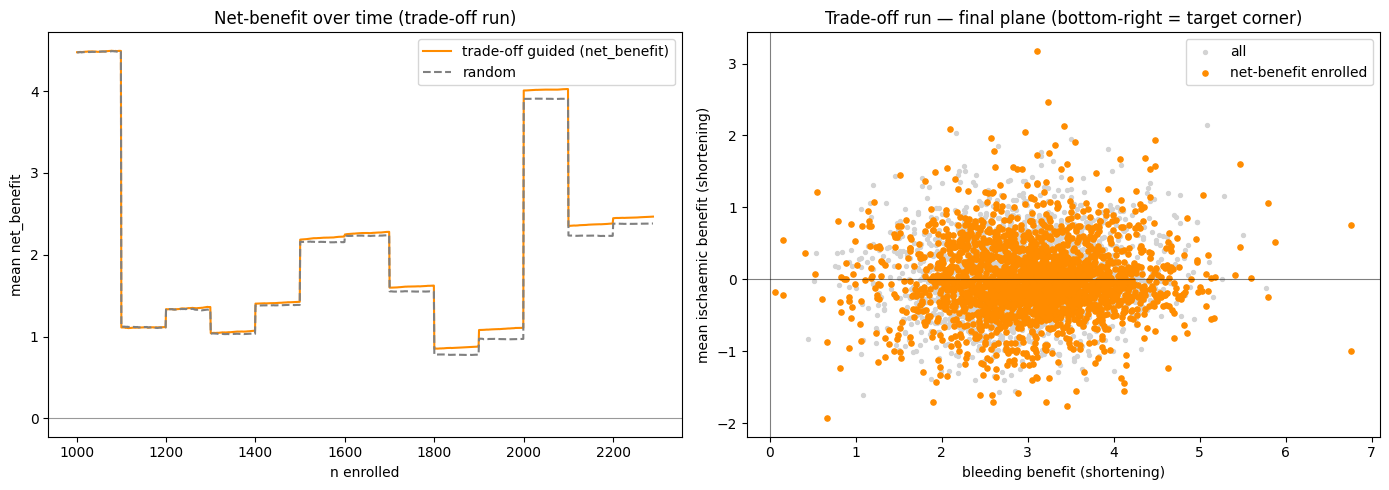

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_nb['n'], hist_nb['nb_sel'], label='trade-off guided (net_benefit)', color='darkorange')
axes[0].plot(hist_nb['n'], hist_nb['nb_rnd'], label='random', color='grey', ls='--')
axes[0].axhline(0, color='k', lw=.8, alpha=.4)
axes[0].set(xlabel='n enrolled', ylabel='mean net_benefit', title='Net-benefit over time (trade-off run)')
axes[0].legend()

isch_nb = weighted_isch({k: z(net_benefit_frame[k]) for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)
axes[1].scatter(net_benefit_frame['bleed'], isch_nb, s=8, color='lightgrey', label='all')
axes[1].scatter(net_benefit_frame['bleed'].iloc[sel_nb], isch_nb.iloc[sel_nb], s=14, color='darkorange',
                label='net-benefit enrolled')
axes[1].axhline(0, color='k', lw=.8, alpha=.5); axes[1].axvline(0, color='k', lw=.8, alpha=.5)
axes[1].set(xlabel='bleeding benefit (shortening)', ylabel='mean ischaemic benefit (shortening)',
            title='Trade-off run — final plane (bottom-right = target corner)')
axes[1].legend()

plt.tight_layout(); plt.show()